# 🧪 Experiment: Chunking Strategy Comparison
## Fast Project — Retrieval Accuracy Benchmark

> **Run 2 (Jul 2026):** Parser fix (ตาราง 7/7 AAFP) + `journal_page` metric  
> **Run 1 baseline:** 72 chunks | Page Recall 0.12 (เทียบ `page` PDF กับเลขวารสาร — ไม่ fair)

**เป้าหมาย:** เปรียบเทียบ 3 Chunking Strategies (Gemini only, fair eval AAFP+URI)

| Strategy | คำอธิบาย | Run 2 source |
|---|---|---|
| **A** (Baseline) | Recursive split + table parser เก่า (บั๊กกลืนตาราง) | `legacy_chunker.py` |
| **B** (Semantic) | Split บน Heading + Prefix | notebook `chunk_v2_semantic` |
| **C** (Production) | Strategy C + parser fix + `patient_group` + `journal_page` | `md_chunker.chunk_md_file()` |

**Metrics ใหม่ Run 2:**
- `Page Recall@5 (journal)` — AAFP เทียบ `journal_page` (628–636) ตาม test case
- `Page Recall@5 (pdf)` — เทียบ `page` (PDF) แบบ Run 1 (อ้างอิง)

> **Run 3:** Eval retrieve = production (`filter → per-source → LLM/BM25 rerank`) — ดู Section 6


---
## Section 0: Setup & Dependencies

In [1]:
# Install dependencies (uncomment ถ้าไม่มี)
# !pip install qdrant-client google-generativeai rank_bm25 pandas matplotlib python-dotenv pymupdf

In [2]:
import sys
import os
import json
import re
import csv
import math
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass, field
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv

# ── Paths ──────────────────────────────────────────────────────
def find_fast_root() -> Path:
    """หา project root จาก cwd — รันได้ทั้ง d:\\Fast และ experiments\\chunking"""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "backend" / "md_chunker.py").is_file():
            return p
    raise FileNotFoundError(
        f"ไม่พบ backend/md_chunker.py — cwd={Path.cwd()}\n"
        "เปิด notebook จากโฟลเดอร์ Fast หรือ experiments/chunking ก็ได้"
    )

FAST_DIR = find_fast_root()
DATA_DIR = FAST_DIR / "rag" / "data"
BACKEND_DIR = FAST_DIR / "backend"
EXPERIMENTS_CHUNKING_DIR = FAST_DIR / "experiments" / "chunking"

# project root สำหรับ `from backend.xxx` ใน md_chunker
sys.path.insert(0, str(FAST_DIR))
sys.path.insert(0, str(EXPERIMENTS_CHUNKING_DIR))

# Load env
load_dotenv(FAST_DIR / ".env")
GOOGLE_API_KEY  = os.getenv("GOOGLE_API_KEY")
TYPHOON_API_KEY = os.getenv("TYPHOON_API_KEY")

print(f"✅ FAST_DIR       : {FAST_DIR.resolve()}")
print(f"✅ BACKEND_DIR    : {BACKEND_DIR.resolve()}")
print(f"✅ GOOGLE_API_KEY : {'set' if GOOGLE_API_KEY else '❌ NOT SET'}")
print(f"✅ TYPHOON_API_KEY: {'set' if TYPHOON_API_KEY else '❌ NOT SET'}")

# ── Run 2 config ──────────────────────────────────────────────
RUN_LABEL = "run2_parser_fix"
RUN1_BASELINE = {
    "C_chunks": 72,
    "Source Recall@5": 0.84,
    "Page Recall@5_pdf": 0.12,
    "MRR": 0.553,
    "Group Accuracy": 1.00,
}

print(f"✅ DATA_DIR       : {DATA_DIR.resolve()}")


✅ FAST_DIR       : D:\Fast
✅ BACKEND_DIR    : D:\Fast\backend
✅ GOOGLE_API_KEY : set
✅ TYPHOON_API_KEY: set
✅ DATA_DIR       : D:\Fast\data


In [3]:
# โหลด md_chunker จาก Fast backend
from backend.md_chunker import (
    ChunkConfig, chunk_md_file, print_summary,
    split_into_blocks, build_chunks, pre_clean_text,
    estimate_tokens, is_heading, heading_level, extract_heading_text
)
from backend.patient_group import (
    infer_patient_group_from_chunk,
    infer_patient_group_from_query,
    groups_compatible,
    filter_groups_for_query,
)

print("✅ md_chunker + patient_group imported")

# โหลด test cases
test_df = pd.read_csv(DATA_DIR / "test_case.csv")
print(f"✅ test_case.csv : {len(test_df)} cases | columns: {list(test_df.columns)}")
test_df.head(3)

✅ md_chunker + patient_group imported
✅ test_case.csv : 57 cases | columns: ['id', 'input', 'expectation', 'case']


,id,input,expectation,case
0,1,แม่พาลูกชายอายุ 3 ขวบมาร้านยา บอกว่าเป็นหวัดมา...,"ยาที่ให้ได้: Paracetamol สำหรับลดไข้, น้ำเกลือ...",ง่าย
1,2,ชายอายุ 25 ปี มาร้านยาบอกว่าเสียงแหบมา 3 วัน ค...,Supportive care: พักเสียง ดื่มน้ำมาก ใช้ไอน้ำ ...,ง่าย
2,3,หญิงอายุ 30 ปี เจ็บคอมา 1 วัน มีน้ำมูกใส ไอมาก...,Supportive care: paracetamol และน้ำอุ่นดื่มมาก...,ง่าย


---
## Section 0.5: Build Ground Truth

ผูก `test_case.csv` แต่ละ case กับ `expected_source`, `expected_page`, `patient_group`  
(ทำ semi-auto จาก `expectation` field — parse `Ref :` ออก)

> ⚠️ ส่วนนี้ทำ **มือ + parse** — ถ้าต้องการ exact `expected_chunk_id` ต้องรัน Section 2 ก่อน แล้วมาเพิ่ม mapping

In [4]:
def parse_ref_from_expectation(text: str) -> dict:
    """Parse 'Ref : AAFP 2022 P.628 , table 1' → {source, pages}"""
    result = {"expected_source": None, "expected_page": None, "expected_pages": [], "ref_raw": None}
    if not isinstance(text, str):
        return result

    ref_match = re.search(r'Ref\s*[:;]\s*(.+?)(?:\[cite|$)', text, re.IGNORECASE | re.DOTALL)
    if not ref_match:
        return result

    ref_raw = ref_match.group(1).strip()
    result["ref_raw"] = ref_raw

    if "AAFP" in ref_raw:
        result["expected_source"] = "AAFP"
    elif "URI" in ref_raw or "แนวทาง" in ref_raw or "2562" in ref_raw:
        result["expected_source"] = "URI"
    elif "dose" in ref_raw.lower() or "supportive" in ref_raw.lower():
        result["expected_source"] = "Dose_supportive"

    pages: list[int] = []
    # เฉพาะ P.628 / P630-631 — ห้ามจับจาก "AAFP 2022" หรือ "table 1"
    for p1, p2 in re.findall(r'(?<![A-Za-z])P\.?\s*(\d+)(?:\s*[-–]\s*(\d+))?', ref_raw, re.IGNORECASE):
        pages.append(int(p1))
        if p2:
            pages.append(int(p2))

    # รองรับ "P.29 , 33" (หน้าที่สองตามหลัง comma)
    for m in re.finditer(
        r'(?<![A-Za-z])P\.?\s*\d+(?:\s*[-–]\s*\d+)?\s*,\s*(\d{1,3})\b',
        ref_raw,
        re.IGNORECASE,
    ):
        pages.append(int(m.group(1)))

    def _is_valid_page(p: int) -> bool:
        # กรองปีที่มักปนใน ref (2022, 2562) แต่ยังรับเลขหน้า PDF 600+ ได้
        if p in (2022, 2023, 2024, 2025, 2562, 2561, 2563):
            return False
        return 1 <= p <= 999

    pages = list(dict.fromkeys(p for p in pages if _is_valid_page(p)))

    result["expected_pages"] = pages
    if pages:
        result["expected_page"] = pages[0]
    return result

# Apply parsing
ref_parsed = test_df["expectation"].apply(parse_ref_from_expectation)
ref_df = pd.DataFrame(ref_parsed.tolist())
test_df = pd.concat([test_df, ref_df], axis=1)
test_df["patient_group_query"] = test_df["input"].apply(infer_patient_group_from_query)

print(f"Ground Truth parsed:")
print(test_df[["id", "expected_source", "expected_page", "expected_pages", "patient_group_query"]].to_string())

Ground Truth parsed:
    id expected_source  expected_page expected_pages patient_group_query
0    1            AAFP          628.0          [628]           pediatric
1    2            AAFP          628.0          [628]               adult
2    3            AAFP          628.0          [628]               adult
3    4             URI           29.0       [29, 33]           pediatric
4    5            AAFP            NaN             []               adult
5    6            AAFP          630.0          [630]             general
6    7            AAFP          630.0     [630, 631]           pediatric
7    8            AAFP          631.0          [631]           pediatric
8    9            AAFP            NaN             []               adult
9   10             NaN            NaN             []           pediatric
10  11             NaN            NaN             []           pediatric
11  12             NaN            NaN             []           pediatric
12  13             URI        

In [5]:
# Hard Negative Test Set (Section 4.5 ล่วงหน้า)
# คำถามกำกวม — ไม่ระบุกลุ่มชัด หรือตั้งใจให้สับสน
hard_negatives = [
    {"id": "HN-01", "input": "amoxicillin dose สำหรับ AOM",
     "expected_source": "AAFP", "expected_page": None,
     "patient_group_query": "general",
     "note": "ไม่ระบุอายุ — ควรถามกลับหรือให้ข้อมูลทั้งเด็กและผู้ใหญ่"},
    {"id": "HN-02", "input": "การรักษา AOM ด้วยยาปฏิชีวนะ",
     "expected_source": "AAFP", "expected_page": None,
     "patient_group_query": "general",
     "note": "ปนเด็ก+ผู้ใหญ่ในเอกสารเดียว — ทดสอบว่าดึงถูกกลุ่มไหม"},
    {"id": "HN-03", "input": "เด็กอายุ 3 ขวบเป็น AOM amoxicillin dose ผู้ใหญ่กี่ mg",
     "expected_source": "AAFP", "expected_page": None,
     "patient_group_query": "pediatric",
     "note": "query ปน pediatric+adult — ทดสอบ filter"},
    {"id": "HN-04", "input": "ขนาดยา penicillin สำหรับคอหอยอักเสบ",
     "expected_source": "AAFP", "expected_page": None,
     "patient_group_query": "general",
     "note": "ไม่ระบุอายุ Centor score"},
    {"id": "HN-05", "input": "URI เด็ก watchful waiting เมื่อไหร่",
     "expected_source": "URI", "expected_page": None,
     "patient_group_query": "pediatric",
     "note": "ควรดึง URI guideline ไม่ใช่ AAFP"},
]
hard_neg_df = pd.DataFrame(hard_negatives)
print(f"Hard Negative Test Set: {len(hard_neg_df)} cases")
hard_neg_df

Hard Negative Test Set: 5 cases


,id,input,expected_source,expected_page,patient_group_query,note
0,HN-01,amoxicillin dose สำหรับ AOM,AAFP,None,general,ไม่ระบุอายุ — ควรถามกลับหรือให้ข้อมูลทั้งเด็กแ...
1,HN-02,การรักษา AOM ด้วยยาปฏิชีวนะ,AAFP,None,general,ปนเด็ก+ผู้ใหญ่ในเอกสารเดียว — ทดสอบว่าดึงถูกกล...
2,HN-03,เด็กอายุ 3 ขวบเป็น AOM amoxicillin dose ผู้ใหญ...,AAFP,None,pediatric,query ปน pediatric+adult — ทดสอบ filter
3,HN-04,ขนาดยา penicillin สำหรับคอหอยอักเสบ,AAFP,None,general,ไม่ระบุอายุ Centor score
4,HN-05,URI เด็ก watchful waiting เมื่อไหร่,URI,None,pediatric,ควรดึง URI guideline ไม่ใช่ AAFP


---
## Section 1: PDF Inspection (พอประมาณ)

Print 3-4 หน้าสำคัญจาก PDF จริง เพื่อเห็นโครงสร้าง (ตาราง, Flowchart, เลขหน้า)


📄 AAFP 2022 — Dose Tables | File: AAFP_2022_Original.pdf
  Page 4:


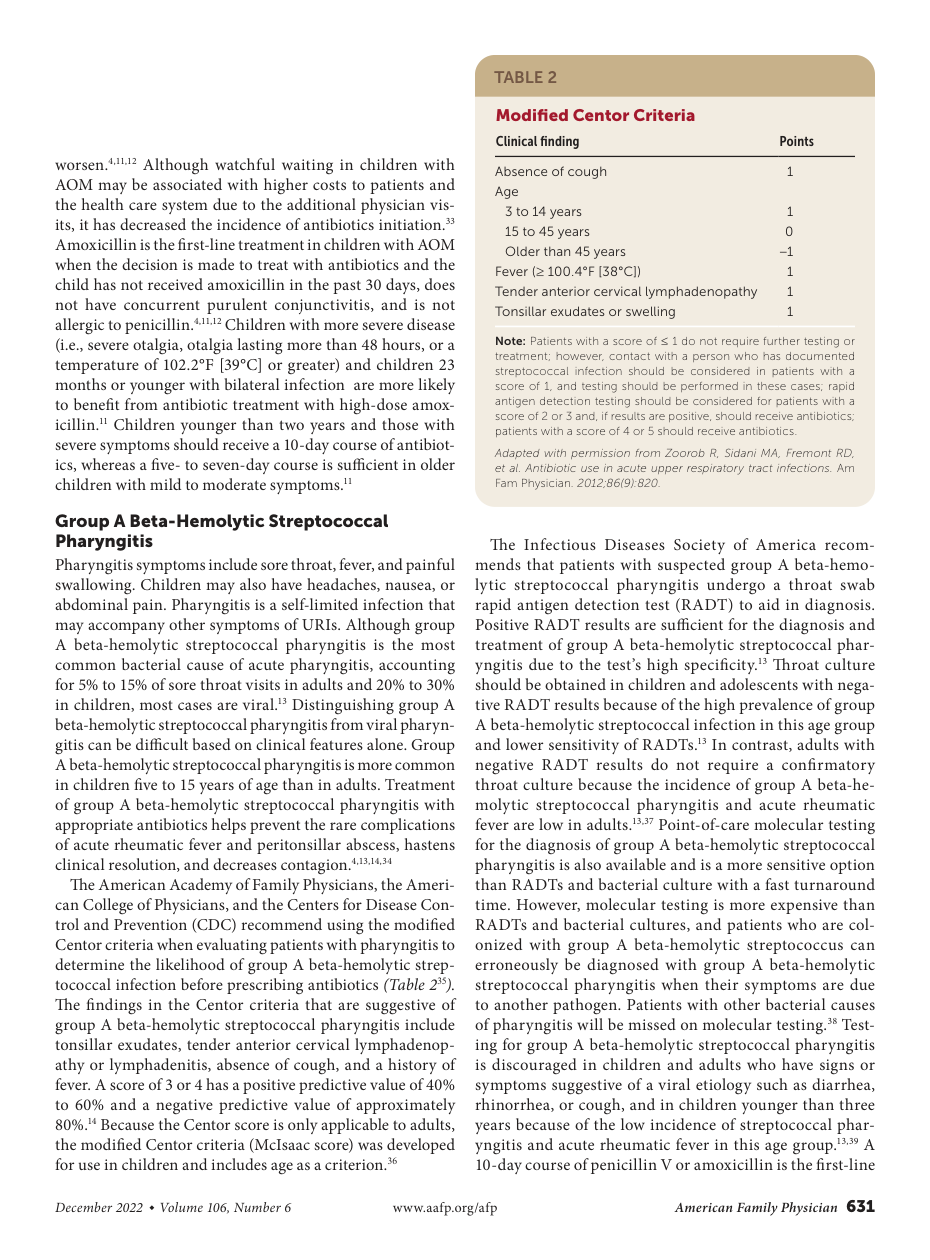

  Page 5:


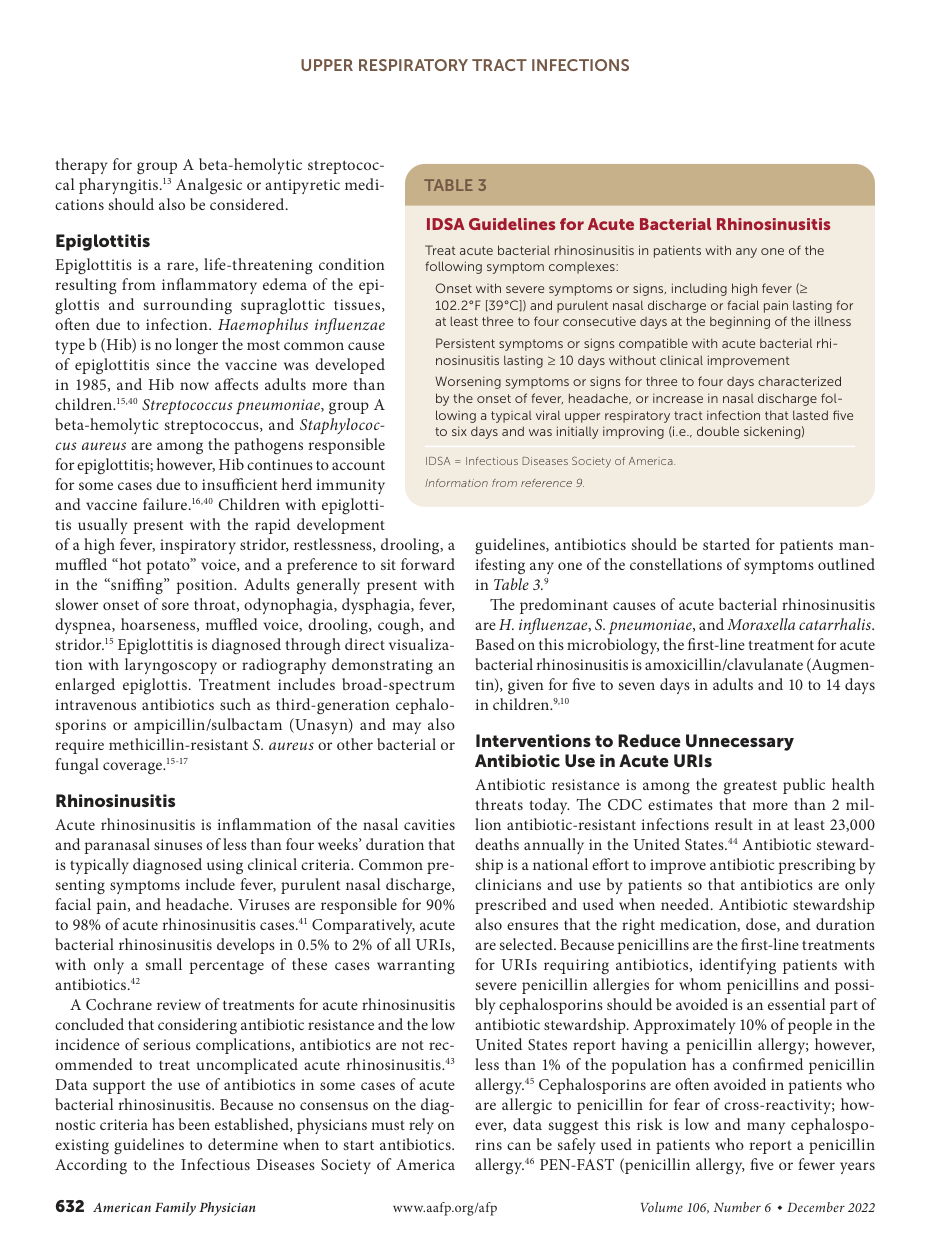

In [6]:
import fitz  # PyMuPDF
from IPython.display import display, Image as IPImage
import io

def render_pdf_page(pdf_path: str, page_num: int, dpi: int = 120) -> bytes:
    """Render PDF page เป็น PNG bytes"""
    doc = fitz.open(pdf_path)
    page = doc[page_num - 1]  # 0-indexed
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    pix = page.get_pixmap(matrix=mat)
    return pix.tobytes("png")

def show_pdf_pages(pdf_path: str, pages: list, title: str = ""):
    """แสดงหลายหน้าจาก PDF"""
    print(f"\n{'='*60}")
    print(f"📄 {title} | File: {Path(pdf_path).name}")
    print(f"{'='*60}")
    for pg in pages:
        print(f"  Page {pg}:")
        try:
            img_bytes = render_pdf_page(pdf_path, pg)
            display(IPImage(data=img_bytes))
        except Exception as e:
            print(f"  ❌ Error: {e}")

# ── AAFP PDF ─────────────────────────────────────────────────
AAFP_PDF = str(DATA_DIR / "AAFP_2022_Original.pdf")
# หน้า 4 = Dose Table AOM, หน้า 5 = Pharyngitis table
show_pdf_pages(AAFP_PDF, pages=[4, 5], title="AAFP 2022 — Dose Tables")

📄 P2_URI.pdf: 72 pages
📄 AAFP_2022_Original.pdf: 9 pages

📄 URI Guideline 2562 — มันชอบมีอ้างอิงและอื่นๆไม่เกีย่วข้อง | File: P2_URI.pdf
  Page 19:


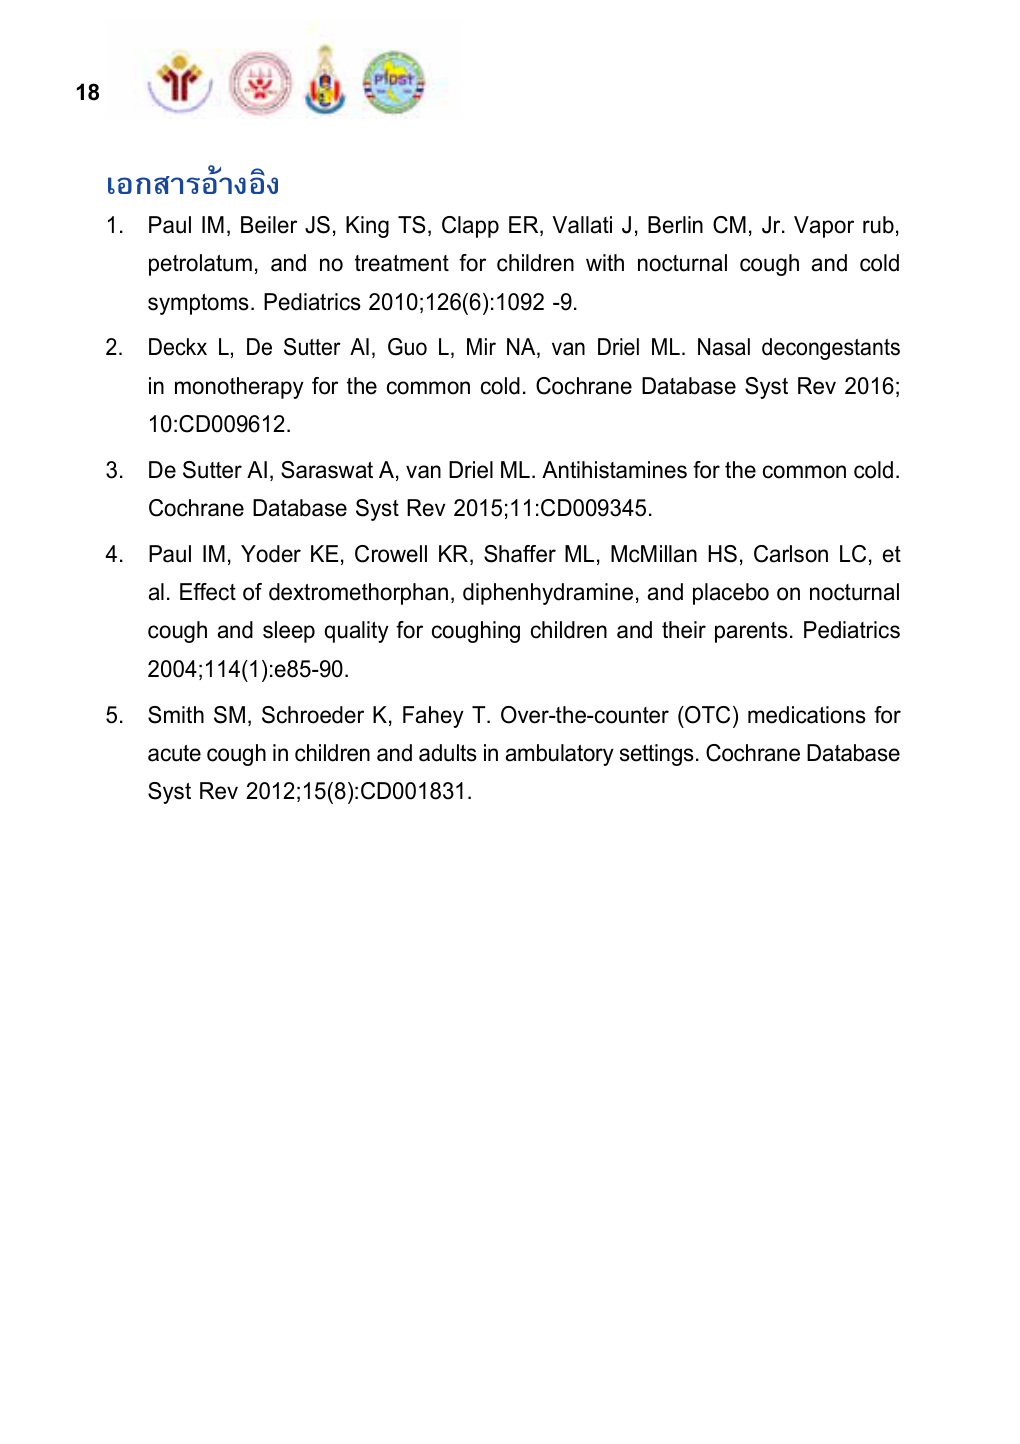

  Page 22:


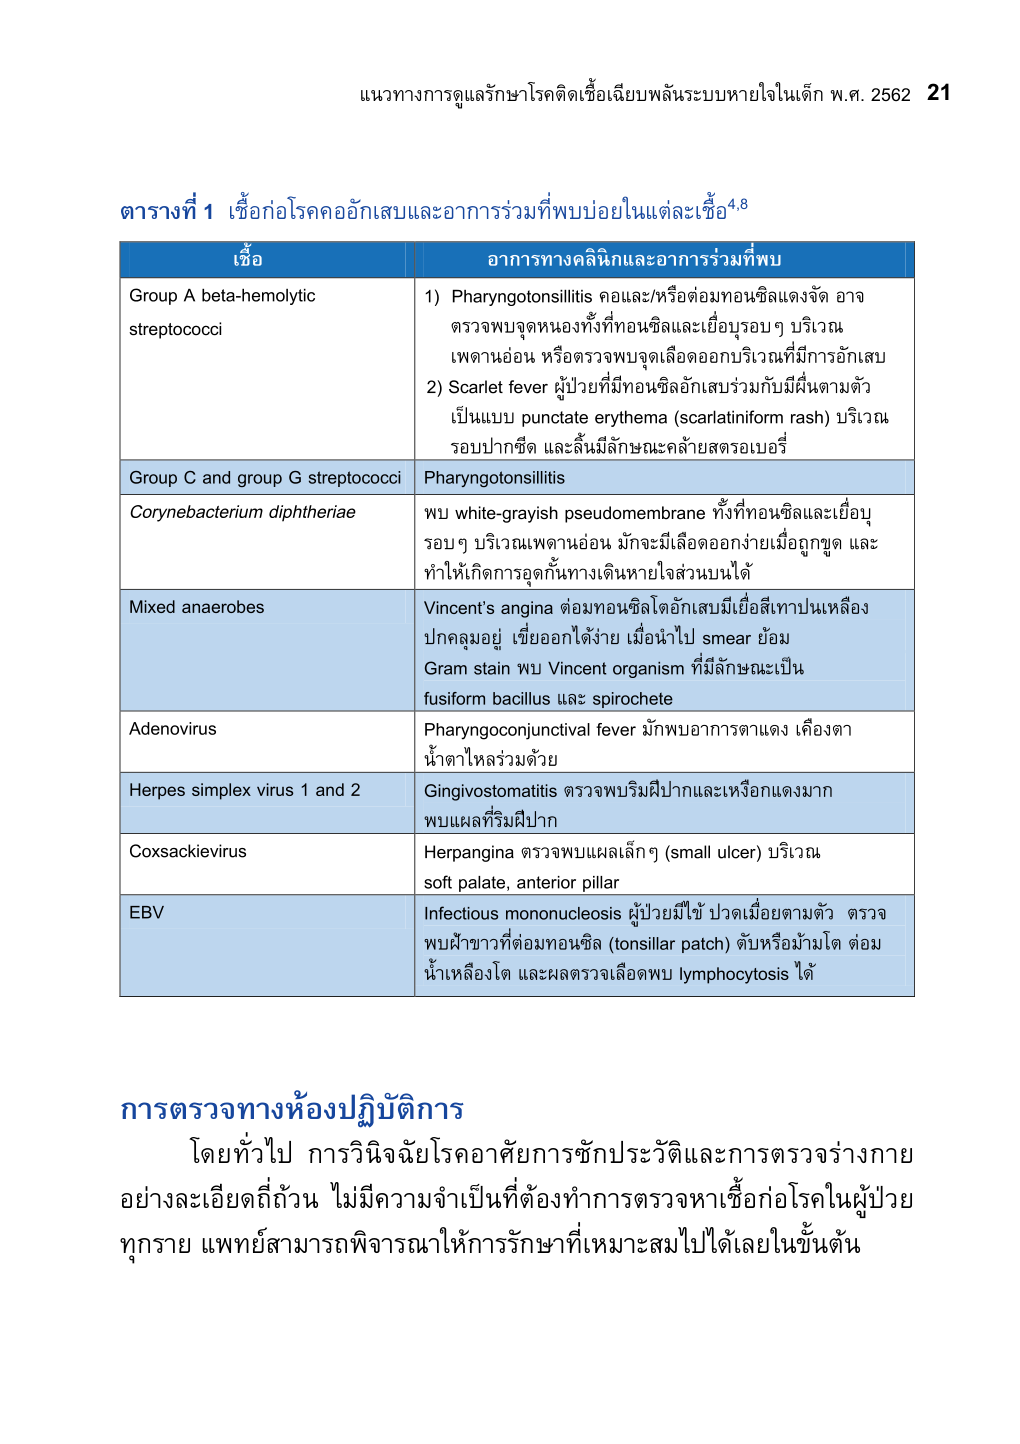

In [7]:
# ── URI PDF (P2_URI.pdf) ──────────────────────────────────────
URI_PDF = str(DATA_DIR / "P2_URI.pdf")

def get_pdf_info(pdf_path: str):
    doc = fitz.open(pdf_path)
    print(f"📄 {Path(pdf_path).name}: {len(doc)} pages")
    return doc

uri_doc = get_pdf_info(URI_PDF)
aafp_doc = get_pdf_info(AAFP_PDF)

# Print 2 หน้าแรกจาก URI ที่น่าจะมี flowchart/ตาราง
show_pdf_pages(URI_PDF, pages=[19, 22], title="URI Guideline 2562 — มันชอบมีอ้างอิงและอื่นๆไม่เกีย่วข้อง")

---
## Section 2: Strategy A — Baseline (Legacy)

ใช้ `legacy_chunker.py` — recursive split + table parser เก่า (ก่อน parser fix Jul 2026)


In [8]:
# ── Strategy A: legacy baseline ───────────────────────────────
from legacy_chunker import chunk_strategy_a

cfg_A = ChunkConfig(overlap_tokens=100)  # config เดิมก่อน Strategy C

chunks_A_aafp = chunk_strategy_a(str(DATA_DIR / "AAFP.md"), source_name="AAFP", config=cfg_A)
chunks_A_uri  = chunk_strategy_a(str(DATA_DIR / "URI.md"),  source_name="URI",  config=cfg_A)
chunks_A = chunks_A_aafp + chunks_A_uri

print(f"Strategy A — AAFP: {len(chunks_A_aafp)} chunks | URI: {len(chunks_A_uri)} chunks | Total: {len(chunks_A)}")
aafp_tables_A = sum(1 for c in chunks_A_aafp if c["type"] == "table_html")
print(f"  AAFP table_html: {aafp_tables_A} (Run2 production ควรได้ 7)")
print_summary(chunks_A)


Strategy A — AAFP: 12 chunks | URI: 67 chunks | Total: 79
  AAFP table_html: 4 (Run2 production ควรได้ 7)

[SUMMARY] total  : 79 chunks
[SUMMARY] tokens : avg=476  min=25  max=5802
[SUMMARY] types  :
           table_html      10 chunks
           text            69 chunks



In [9]:
# ── แสดงปัญหาที่ชัดเจน: chunk ที่ใหญ่เกิน 500 tokens ──────────
oversized = [c for c in chunks_A if c["tokens_approx"] > 500]
table_chunks = [c for c in chunks_A if c["type"] in ("table_html", "table_md")]
oversized_tables = [c for c in table_chunks if c["tokens_approx"] > 400]

print(f"\n⚠️  Chunks เกิน 500 tokens: {len(oversized)}")
print(f"⚠️  Table chunks: {len(table_chunks)} | ที่ใหญ่เกิน 400 tok: {len(oversized_tables)}")

print("\n📊 Table chunks ที่ใหญ่ที่สุด (Top 5):")
sorted_tables = sorted(table_chunks, key=lambda x: x["tokens_approx"], reverse=True)[:5]
for c in sorted_tables:
    print(f"  [{c['chunk_id']}] {c['tokens_approx']} tokens | Page {c['page']} | {c['heading'][:60]}")


⚠️  Chunks เกิน 500 tokens: 11
⚠️  Table chunks: 10 | ที่ใหญ่เกิน 400 tok: 9

📊 Table chunks ที่ใหญ่ที่สุด (Top 5):
  [URI_0045] 5802 tokens | Page 40 | การตรวจทางห้องปฏิบัติการ > แนวทางการป้องกันไซนัสอักเสบ (prev
  [AAFP_0011] 3166 tokens | Page 8 | UPPER RESPIRATORY TRACT INFECTIONS > TABLE 5 Physician and P
  [AAFP_0009] 2418 tokens | Page 6 | Antibiotic Use in Acute Upper Respiratory Tract Infections >
  [AAFP_0003] 2416 tokens | Page 2 | Antibiotic Use in Acute Upper Respiratory Tract Infections >
  [AAFP_0006] 1981 tokens | Page 4 | Antibiotic Use in Acute Upper Respiratory Tract Infections >


In [10]:
# ── แสดงตัวอย่าง chunk ที่ heading ปนกลุ่มเด็ก/ผู้ใหญ่ ─────────
# Chunk ที่ heading เป็นแค่ parent (ไม่มี > Children หรือ > Adults)
heading_only_parent = [
    c for c in chunks_A
    if c["heading"] and ">" not in c["heading"]
    and any(kw in c["content"].lower() for kw in ["children", "adults", "เด็ก", "ผู้ใหญ่"])
]
print(f"\n⚠️  Chunks ที่ heading ไม่แยกกลุ่มผู้ป่วย (มีทั้งเด็ก/ผู้ใหญ่ในเนื้อหา): {len(heading_only_parent)}")
for c in heading_only_parent[:3]:
    print(f"\n  chunk_id : {c['chunk_id']}")
    print(f"  heading  : {c['heading']}")
    print(f"  tokens   : {c['tokens_approx']}")
    print(f"  preview  : {c['content'][:200]}...")


⚠️  Chunks ที่ heading ไม่แยกกลุ่มผู้ป่วย (มีทั้งเด็ก/ผู้ใหญ่ในเนื้อหา): 17

  chunk_id : URI_0001
  heading  : แนวทางการดูแลรักษา โรคติดเชื้อเฉียบพลันระบบหายใจในเด็ก พ.ศ. 2562
  tokens   : 142
  preview  : [Source: URI | Page: 4 | Section: แนวทางการดูแลรักษา โรคติดเชื้อเฉียบพลันระบบหายใจในเด็ก พ.ศ. 2562]

จัดพิมพ์โดย



สมาคมโรคระบบหายใจและเวชบำบัดวิกฤตในเด็ก
ราชวิทยาลัยกุมารแพทย์แห่งประเทศไทย









...

  chunk_id : URI_0002
  heading  : คำนำ
  tokens   : 439
  preview  : [Source: URI | Page: 5 | Section: คำนำ]

โรคติดเชื้อเฉียบพลันระบบหายใจ เป็นโรคที่พบบ่อยในเด็ก เป็นปัญหาสาธารณสุขที่สำคัญของประเทศไทย ถ้าเด็กที่ป่วยด้วยโรคนี้ได้รับการดูแลรักษาที่ไม่ถูกต้องเหมาะสม อาจเ...

  chunk_id : URI_0003
  heading  : คำนำ
  tokens   : 223
  preview  : [Source: URI | Page: 5 | Section: คำนำ]

อดจนกุมารแพทย์ที่ได้ร่วมกันทำประชาพิจารณ์ ในการประชุมวิชาการของสมาคมโรคระบบหายใจและเวชบำบัดวิกฤตในเด็ก วันที่ 28-30 มีนาคม 2561 และงานประชุมวิชาการของราชวิทยาล...


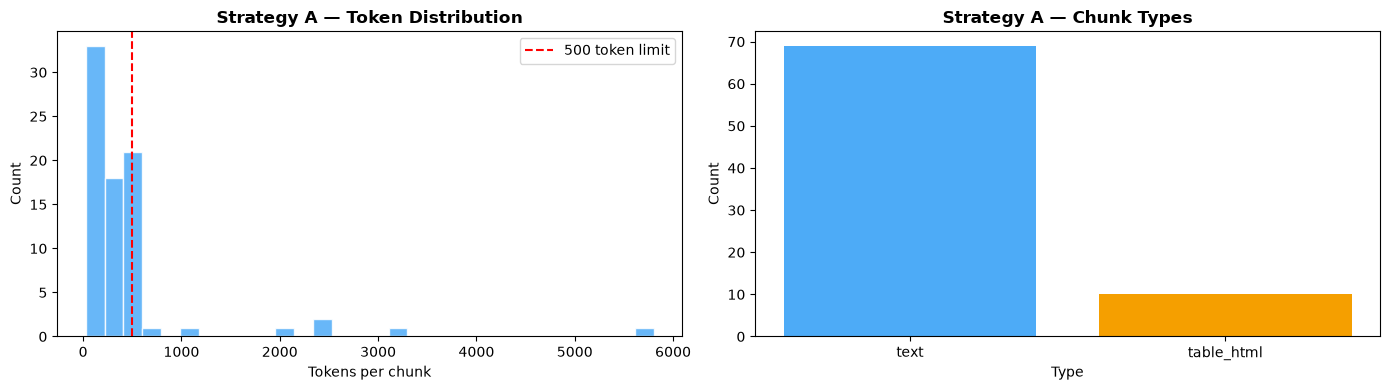

Strategy A stats: avg=476 | min=25 | max=5802 tokens


In [11]:
# ── Visualize token distribution ─────────────────────────────
tokens_A = [c["tokens_approx"] for c in chunks_A]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(tokens_A, bins=30, color="#4dabf7", edgecolor="white", alpha=0.85)
axes[0].axvline(500, color="red", linestyle="--", label="500 token limit")
axes[0].set_title("Strategy A — Token Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tokens per chunk")
axes[0].set_ylabel("Count")
axes[0].legend()

# Type breakdown
type_counts = defaultdict(int)
for c in chunks_A:
    type_counts[c["type"]] += 1
axes[1].bar(type_counts.keys(), type_counts.values(), color=["#4dabf7", "#f59f00", "#51cf66"])
axes[1].set_title("Strategy A — Chunk Types", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("experiment_strategy_A.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Strategy A stats: avg={sum(tokens_A)//len(tokens_A)} | min={min(tokens_A)} | max={max(tokens_A)} tokens")

---
## Section 3: Strategy B — Semantic Heading Split + Prefix

ตัดที่ Heading boundary เป็นหลัก + แปะ `[Context: H1 > H2]` ทุก chunk  
(ทดสอบใน notebook ก่อน — ยังไม่แก้ไฟล์ต้นฉบับ)

In [12]:
def chunk_v2_semantic(
    md_path: str,
    source_name: str = None,
    max_tokens: int = 500,
    overlap_tokens: int = 80,
    chars_per_token: int = 4,
    include_context_prefix: bool = True,
) -> list[dict]:
    """
    Strategy B: Heading-based split + Context prefix
    - ตัดเมื่อพบ Heading ใหม่ (ไม่ใช่ Hard cut ที่ token)
    - ถ้า section ยาวเกิน max_tokens → Sliding Window
    - ทุก chunk มี [Context: H1 > H2 > H3] นำหน้า
    - ยังคง output schema เดิม: chunk_id, source, page, heading, type, content, tokens_approx
    """
    cfg = ChunkConfig(
        max_tokens=max_tokens,
        overlap_tokens=overlap_tokens,
        chars_per_token=chars_per_token,
        include_prefix=True,
    )
    md_path_obj = Path(md_path)
    source_name = source_name or md_path_obj.stem
    text = md_path_obj.read_text(encoding="utf-8")
    text = pre_clean_text(text, cfg)
    blocks = split_into_blocks(text, cfg)

    chunks = []
    chunk_id = 0
    current_page = 1
    headings = {1: "", 2: "", 3: "", 4: ""}
    section_buffer = []  # (block_type, content) list in current section

    def heading_path():
        return " > ".join(filter(None, [headings[1], headings[2], headings[3]]))

    def context_prefix(hpath):
        if not include_context_prefix or not hpath:
            return ""
        return f"[Context: {hpath}]\n"

    def make_chunk_v2(content, ctype, page, hpath, extra_meta=None):
        nonlocal chunk_id
        ctx = context_prefix(hpath)
        src_prefix = f"[Source: {source_name} | Page: {page} | Section: {hpath}]\n\n" if hpath \
                     else f"[Source: {source_name} | Page: {page}]\n\n"
        full = src_prefix + ctx + content.strip()
        c = {
            "chunk_id"     : f"{source_name}_{chunk_id:04d}",
            "source"       : source_name,
            "page"         : page,
            "heading"      : hpath,
            "type"         : ctype,
            "content"      : full,
            "tokens_approx": estimate_tokens(full, cfg),
        }
        if extra_meta:
            c.update(extra_meta)
        chunk_id += 1
        return c

    def flush_section_buffer(page, hpath):
        """Flush section buffer — ถ้ายาวเกิน max_tokens ใช้ Sliding Window"""
        text_parts = [b["content"] for b in section_buffer if b["type"] == "text"]
        text_combined = "\n\n".join(text_parts).strip()

        if not text_combined:
            return []

        tok_count = estimate_tokens(text_combined, cfg)
        if tok_count <= max_tokens:
            return [make_chunk_v2(text_combined, "text", page, hpath)]

        # Sliding Window: ตัดทีละ paragraph
        result_chunks = []
        paragraphs = re.split(r'\n{2,}', text_combined)
        buffer = ""
        overlap_chars = overlap_tokens * chars_per_token

        for para in paragraphs:
            if not para.strip():
                continue
            candidate = (buffer + "\n\n" + para).strip() if buffer else para
            if estimate_tokens(candidate, cfg) > max_tokens and buffer:
                result_chunks.append(make_chunk_v2(buffer, "text", page, hpath))
                # overlap: เอาท้ายๆ buffer มาต่อ
                overlap = buffer[-overlap_chars:] if len(buffer) > overlap_chars else buffer
                buffer = (overlap + "\n\n" + para).strip()
            else:
                buffer = candidate

        if buffer.strip():
            result_chunks.append(make_chunk_v2(buffer, "text", page, hpath))
        return result_chunks

    for block in blocks:
        btype = block["type"]

        if btype == "page_marker":
            current_page = block.get("page") or current_page

        elif btype == "blank":
            pass  # ignore blank blocks

        elif btype == "heading":
            # Flush buffer ก่อนเปลี่ยน heading
            if section_buffer:
                chunks.extend(flush_section_buffer(current_page, heading_path()))
                section_buffer = []
            # Update heading state
            lvl = block["level"]
            htxt = extract_heading_text(block["content"])
            headings[lvl] = htxt
            for l in range(lvl + 1, 5):
                headings[l] = ""

        elif btype in ("table_html", "table_md"):
            # Flush text buffer ก่อน
            if section_buffer:
                chunks.extend(flush_section_buffer(current_page, heading_path()))
                section_buffer = []
            # ตารางอยู่ปนกับ text (Strategy B ยังไม่ isolate table)
            chunks.append(make_chunk_v2(
                block["content"], btype, current_page, heading_path()
            ))

        elif btype == "text":
            section_buffer.append(block)

    # Flush ที่เหลือ
    if section_buffer:
        chunks.extend(flush_section_buffer(current_page, heading_path()))

    return chunks


# รัน Strategy B
chunks_B_aafp = chunk_v2_semantic(str(DATA_DIR / "AAFP.md"), source_name="AAFP")
chunks_B_uri  = chunk_v2_semantic(str(DATA_DIR / "URI.md"),  source_name="URI")
chunks_B = chunks_B_aafp + chunks_B_uri

print(f"Strategy B — AAFP: {len(chunks_B_aafp)} chunks | URI: {len(chunks_B_uri)} chunks | Total: {len(chunks_B)}")

Strategy B — AAFP: 38 chunks | URI: 94 chunks | Total: 132


In [13]:
# เปรียบเทียบ A vs B
tokens_B = [c["tokens_approx"] for c in chunks_B]
oversized_B = [c for c in chunks_B if c["tokens_approx"] > 500]

print(f"Strategy A: {len(chunks_A)} chunks | avg={sum(tokens_A)//len(tokens_A)} | max={max(tokens_A)} | oversized={len([c for c in chunks_A if c['tokens_approx']>500])}")
print(f"Strategy B: {len(chunks_B)} chunks | avg={sum(tokens_B)//len(tokens_B)} | max={max(tokens_B)} | oversized={len(oversized_B)}")

# ตรวจว่า heading แยกกลุ่มได้ดีขึ้นไหม
b_with_children = [c for c in chunks_B if "children" in c["heading"].lower() or "เด็ก" in c["heading"]]
b_with_adults   = [c for c in chunks_B if "adults" in c["heading"].lower() or "ผู้ใหญ่" in c["heading"]]
print(f"\nStrategy B — chunks ที่ heading ระบุ 'children': {len(b_with_children)}")
print(f"Strategy B — chunks ที่ heading ระบุ 'adults'  : {len(b_with_adults)}")

# แสดง example ที่ดีขึ้น
if b_with_children:
    ex = b_with_children[0]
    print(f"\n✅ ตัวอย่าง chunk เด็กใน Strategy B:")
    print(f"   chunk_id : {ex['chunk_id']}")
    print(f"   heading  : {ex['heading']}")
    print(f"   content  : {ex['content'][:300]}...")

Strategy A: 79 chunks | avg=476 | max=5802 | oversized=11
Strategy B: 132 chunks | avg=324 | max=996 | oversized=28

Strategy B — chunks ที่ heading ระบุ 'children': 7
Strategy B — chunks ที่ heading ระบุ 'adults'  : 0

✅ ตัวอย่าง chunk เด็กใน Strategy B:
   chunk_id : URI_0001
   heading  : แนวทางการดูแลรักษา โรคติดเชื้อเฉียบพลันระบบหายใจในเด็ก พ.ศ. 2562
   content  : [Source: URI | Page: 4 | Section: แนวทางการดูแลรักษา โรคติดเชื้อเฉียบพลันระบบหายใจในเด็ก พ.ศ. 2562]

[Context: แนวทางการดูแลรักษา โรคติดเชื้อเฉียบพลันระบบหายใจในเด็ก พ.ศ. 2562]
จัดพิมพ์โดย

สมาคมโรคระบบหายใจและเวชบำบัดวิกฤตในเด็ก
ราชวิทยาลัยกุมารแพทย์แห่งประเทศไทย

ชื่อหนังสือ แนวทางการดูแลรักษาโรคต...


---
## Section 4: Strategy C — Production (`md_chunker.py`)

ใช้ production code โดยตรง (Strategy C + parser fix + `journal_page`)  
Fair eval: AAFP + URI เท่านั้น (ยังไม่รวม Dose supportive)


In [14]:
# ── Strategy C: production chunk_md_file ─────────────────────
cfg_C = ChunkConfig(
    max_tokens=500,
    overlap_tokens=80,
    chars_per_token=4,
    include_prefix=True,
    table_chunk_mode="full",
)

chunks_C_aafp = chunk_md_file(str(DATA_DIR / "AAFP.md"), source_name="AAFP", config=cfg_C)
chunks_C_uri  = chunk_md_file(str(DATA_DIR / "URI.md"),  source_name="URI",  config=cfg_C)
chunks_C = chunks_C_aafp + chunks_C_uri

print(f"Strategy C — AAFP: {len(chunks_C_aafp)} chunks | URI: {len(chunks_C_uri)} chunks | Total: {len(chunks_C)}")
aafp_tables_C = sum(1 for c in chunks_C_aafp if c["type"] == "table_html")
print(f"  AAFP table_html: {aafp_tables_C} (คาดหวัง 7)")
from collections import Counter
print(f"  patient_group: {dict(Counter(c.get('patient_group','?') for c in chunks_C))}")
print(f"  มี journal_page: {sum(1 for c in chunks_C if 'journal_page' in c)} chunks")
print_summary(chunks_C)


Strategy C — AAFP: 38 chunks | URI: 94 chunks | Total: 132
  AAFP table_html: 7 (คาดหวัง 7)
  patient_group: {'general': 13, 'both': 17, 'pediatric': 100, 'adult': 2}
  มี journal_page: 131 chunks

[SUMMARY] total  : 132 chunks
[SUMMARY] tokens : avg=325  min=31  max=1000
[SUMMARY] types  :
           table_html      19 chunks
           text            113 chunks



In [15]:
# ── Section 4 (ต่อ): CSV Dose Layer ──────────────────────────
# สร้าง structured dose chunks จาก Dose supportive.csv (schema จริง)

DOSE_CSV_PATH = DATA_DIR / "Dose supportive.csv"
DOSE_SOURCE_NAME = "Dose supportive.csv"

# Column schema จริงของ CSV
COL_GROUP = "กลุ่มยา"
COL_DRUG = "ชื่อสามัญ/ชื่อการค้า"
COL_INDICATION = "ข้อบ่งใช้"
COL_ADULT = "Dose ผู้ใหญ่"
COL_PEDIATRIC = "Dose เด็ก"
COL_RENAL_HEPATIC = "Dose ปรับตามตับ/ไต"
COL_WARNINGS = "ข้อห้ามใช้/ควรระวัง"

if not DOSE_CSV_PATH.exists():
    raise FileNotFoundError(f"ไม่พบ {DOSE_CSV_PATH} — ต้องมี Dose supportive.csv ใน data/")

for enc in ("utf-8-sig", "utf-8", "cp874"):
    try:
        dose_df = pd.read_csv(DOSE_CSV_PATH, encoding=enc)
        break
    except UnicodeDecodeError:
        continue
else:
    raise UnicodeDecodeError(f"อ่าน {DOSE_CSV_PATH} ไม่ได้ — ลอง encoding อื่น")

expected_cols = {COL_GROUP, COL_DRUG, COL_INDICATION, COL_ADULT, COL_PEDIATRIC}
missing = expected_cols - set(dose_df.columns)
if missing:
    raise ValueError(f"CSV schema ไม่ตรง — ขาด columns: {missing}\nพบ: {list(dose_df.columns)}")

print(f"✅ {DOSE_SOURCE_NAME} loaded: {len(dose_df)} rows")
print(dose_df[[COL_DRUG, COL_GROUP, COL_ADULT, COL_PEDIATRIC]].head(3).to_string())

✅ Dose supportive.csv loaded: 56 rows
  ชื่อสามัญ/ชื่อการค้า        กลุ่มยา                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Dose ผู้ใหญ่                                                                                                                                                      

In [16]:
def _cell_text(val) -> str:
    if pd.isna(val):
        return ""
    return str(val).strip()


def _short(text: str, max_len: int = 80) -> str:
    text = _cell_text(text)
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


def dose_df_to_chunks(df: pd.DataFrame) -> list[dict]:
    """แปลง Dose supportive.csv เป็น structured text chunks (1 row → สูงสุด 2 chunks: adult + pediatric)"""
    chunks = []
    chunk_seq = 0

    for row_idx, row in df.iterrows():
        drug_group = _cell_text(row.get(COL_GROUP))
        drug_name = _cell_text(row.get(COL_DRUG))
        indication = _cell_text(row.get(COL_INDICATION))
        renal_hepatic = _cell_text(row.get(COL_RENAL_HEPATIC))
        warnings = _cell_text(row.get(COL_WARNINGS))

        dose_variants = [
            ("adult", "ผู้ใหญ่", COL_ADULT),
            ("pediatric", "เด็ก", COL_PEDIATRIC),
        ]

        for patient_group, group_label, dose_col in dose_variants:
            dose_text = _cell_text(row.get(dose_col))
            if not dose_text:
                continue

            heading = f"{drug_name} Dosing — {_short(indication)} — {group_label}"
            content_parts = [
                f"[Context: {DOSE_SOURCE_NAME} | {drug_name} | {patient_group}]",
                "",
                f"Drug Group: {drug_group}",
                f"Drug: {drug_name}",
                f"Indication: {indication}",
                f"Patient Group: {patient_group}",
                f"Dose ({group_label}): {dose_text}",
            ]
            if renal_hepatic:
                content_parts.append(f"Renal/Hepatic Adjustment: {renal_hepatic}")
            if warnings:
                content_parts.append(f"Warnings/Contraindications: {warnings}")
            content_parts.append(f"Ref: {DOSE_SOURCE_NAME}")

            content = "\n".join(content_parts)
            keywords = [k for k in [drug_name, drug_group] if k]

            chunks.append({
                "chunk_id": f"dose_sup_{chunk_seq:03d}",
                "source": DOSE_SOURCE_NAME,
                "page": 0,
                "heading": heading,
                "type": "dose_table",
                "content": content,
                "tokens_approx": len(content) // 4,
                "patient_group": patient_group,
                "retrievable_keywords": keywords,
            })
            chunk_seq += 1

    return chunks


dose_chunks = dose_df_to_chunks(dose_df)

# Fair eval: เปรียบเทียบแค่ AAFP + URI (เหมือน A/B) — ยังไม่รวม Dose supportive
chunks_C_eval = chunks_C
chunks_C_full = chunks_C  # alias สำหรับ cell อื่นในรอบนี้

print(f"Strategy C (Eval — AAFP+URI only) — Total: {len(chunks_C_eval)} chunks")
print(f"  - Dose supportive: {len(dose_chunks)} chunks (เก็บไว้ แต่ยังไม่รวมในการวัดผล)")

print("\n📊 Dose chunks (deferred, sample):")
for dc in dose_chunks[:3]:
    print(f"  [{dc['chunk_id']}] {dc['heading']} | {dc['patient_group']}")

Strategy C (Eval — AAFP+URI only) — Total: 132 chunks
  - Dose supportive: 97 chunks (เก็บไว้ แต่ยังไม่รวมในการวัดผล)

📊 Dose chunks (deferred, sample):
  [dose_sup_000] Chlorpheniramine Dosing — Upper respiratory tract conditions: Temporary relief of symptoms (runny nose;... — ผู้ใหญ่ | adult
  [dose_sup_001] Chlorpheniramine Dosing — Upper respiratory tract conditions: Temporary relief of symptoms (runny nose;... — เด็ก | pediatric
  [dose_sup_002] Brompheniramine Dosing — Brompheniramine is an antihistamine that is used to treat sneezing, runny nos... — ผู้ใหญ่ | adult


---
## Section 4.5: Hard Negative Analysis

แสดง chunk ที่จะถูกดึงจาก Hard Negative queries ด้วย keyword matching (ก่อน embed)

In [17]:
def keyword_search(query: str, chunks: list[dict], top_k: int = 3) -> list[dict]:
    """Simple keyword search (BM25-like) สำหรับ preview ก่อน embed"""
    query_terms = query.lower().split()
    scores = []
    for c in chunks:
        content_lower = c["content"].lower()
        score = sum(content_lower.count(t) for t in query_terms)
        scores.append((score, c))
    scores.sort(key=lambda x: x[0], reverse=True)
    return [c for _, c in scores[:top_k]]

print("🔍 Hard Negative — Keyword Search Preview (Strategy C, AAFP+URI only)")
print("=" * 70)
for hn in hard_negatives:
    print(f"\nQuery: '{hn['input']}'")
    print(f"Note : {hn['note']}")
    results = keyword_search(hn["input"], chunks_C_full, top_k=3)
    for i, r in enumerate(results, 1):
        pg = r.get("patient_group", "N/A")
        print(f"  [{i}] {r['chunk_id']} | page={r['page']} | group={pg} | {r['heading'][:50]}")

🔍 Hard Negative — Keyword Search Preview (Strategy C, AAFP+URI only)

Query: 'amoxicillin dose สำหรับ AOM'
Note : ไม่ระบุอายุ — ควรถามกลับหรือให้ข้อมูลทั้งเด็กและผู้ใหญ่
  [1] AAFP_0023 | page=6 | group=both | UPPER RESPIRATORY TRACT INFECTIONS > Interventions
  [2] URI_0072 | page=56 | group=pediatric | คำแนะนำสำหรับการรักษา AOM > ชนิดและระยะเวลาในการให
  [3] URI_0074 | page=56 | group=pediatric | คำแนะนำสำหรับการรักษา AOM > ชนิดและระยะเวลาในการให

Query: 'การรักษา AOM ด้วยยาปฏิชีวนะ'
Note : ปนเด็ก+ผู้ใหญ่ในเอกสารเดียว — ทดสอบว่าดึงถูกกลุ่มไหม
  [1] URI_0073 | page=56 | group=pediatric | คำแนะนำสำหรับการรักษา AOM > ชนิดและระยะเวลาในการให
  [2] URI_0069 | page=53 | group=pediatric | โรคหูชั้นกลางอักเสบเฉียบพลัน (Acute otitis media) 
  [3] AAFP_0008 | page=3 | group=both | UPPER RESPIRATORY TRACT INFECTIONS > Acute Otitis 

Query: 'เด็กอายุ 3 ขวบเป็น AOM amoxicillin dose ผู้ใหญ่กี่ mg'
Note : query ปน pediatric+adult — ทดสอบ filter
  [1] AAFP_0023 | page=6 | group=both | UPPER RESPIRATO

---
## Section 5: Embedding — Gemini only (Fair Eval: AAFP + URI)

Embed chunks ทั้ง 3 Strategies ด้วย **Gemini embedding-001** → 3 Qdrant local collections

> **Fair comparison:** Strategy C ใช้แค่ `AAFP.md + URI.md` (ไม่รวม Dose supportive ในรอบนี้)  
> BGE-M3 skip — ไม่ต้องโหลด torch

| Collection | Chunking | Embedding |
|---|---|---|
| `exp_A_gemini` | Strategy A | Gemini embedding-001 |
| `exp_B_gemini` | Strategy B | Gemini embedding-001 |
| `exp_C_gemini` | Strategy C (Full) | Gemini embedding-001 |

In [18]:
import gc
import google.generativeai as genai
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct
)

genai.configure(api_key=GOOGLE_API_KEY)

# Qdrant local — เก็บใน experiments/chunking (แยกจาก production qdrant_db)
EXP_QDRANT_DIR = str(EXPERIMENTS_CHUNKING_DIR / "qdrant_experiment_fair")

# ปิด client เก่าก่อน re-run cell นี้ (กัน lock error)
_old_qclient = globals().get("qclient")
if _old_qclient is not None:
    try:
        _old_qclient.close()
    except Exception:
        pass
    del _old_qclient
    gc.collect()

qclient = QdrantClient(path=EXP_QDRANT_DIR)
print(f"✅ Qdrant experiment client: {EXP_QDRANT_DIR}")

GEMINI_EMBED_MODEL = "models/gemini-embedding-001"
GEMINI_DIM = 3072

def embed_gemini(texts: list[str], task_type: str = "RETRIEVAL_DOCUMENT", batch_size: int = 10) -> list[list[float]]:
    """Embed list of texts ด้วย Gemini embedding-001"""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        result = genai.embed_content(
            model=GEMINI_EMBED_MODEL,
            content=batch,
            task_type=task_type,
        )
        all_embeddings.extend(result["embedding"])
        print(f"  Gemini embedded {min(i+batch_size, len(texts))}/{len(texts)}", end="\r")
    print()
    return all_embeddings

print("✅ Gemini embed function ready")


d:\mini\envs\new_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\eieiz\AppData\Local\Temp\ipykernel_4368\54016334.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ Qdrant experiment client: d:\Fast\experiments\chunking\qdrant_experiment_fair
✅ Gemini embed function ready


In [19]:
# BGE-M3 skipped — ใช้แค่ Gemini (ไม่ต้อง torch ตอน deploy)
USE_BGE = False
print("ℹ️  BGE-M3 skipped — Gemini embedding only")

ℹ️  BGE-M3 skipped — Gemini embedding only


In [20]:
def create_or_reset_collection(client: QdrantClient, name: str, dim: int):
    """สร้าง collection ใหม่ (ลบเก่าถ้ามี)"""
    existing = [c.name for c in client.get_collections().collections]
    if name in existing:
        client.delete_collection(name)
    client.create_collection(
        collection_name=name,
        vectors_config=VectorParams(size=dim, distance=Distance.COSINE),
    )
    print(f"  ✅ Collection '{name}' created (dim={dim})")


def upsert_chunks(client: QdrantClient, collection_name: str, chunks: list[dict], vectors: list[list[float]]):
    """Upsert chunks + vectors เข้า Qdrant"""
    points = [
        PointStruct(
            id=i,
            vector=vectors[i],
            payload={
                "chunk_id"     : chunks[i]["chunk_id"],
                "source"       : chunks[i]["source"],
                "page"         : chunks[i]["page"],
                "journal_page" : chunks[i].get("journal_page"),
                "heading"      : chunks[i]["heading"],
                "type"         : chunks[i]["type"],
                "content"      : chunks[i]["content"],
                "tokens_approx": chunks[i]["tokens_approx"],
                "patient_group": chunks[i].get("patient_group", "general"),
            },
        )
        for i in range(len(chunks))
    ]
    batch_size = 100
    for i in range(0, len(points), batch_size):
        client.upsert(collection_name=collection_name, points=points[i:i + batch_size])
    print(f"  ✅ Upserted {len(points)} chunks → '{collection_name}'")


print("✅ Helper functions ready")


✅ Helper functions ready


In [21]:
# ── Embed & Index Strategy A ──────────────────────────────────
print("\n📦 Strategy A — Embedding (Gemini)...")
texts_A = [c["content"] for c in chunks_A]

vecs_A_gemini = embed_gemini(texts_A)
create_or_reset_collection(qclient, "exp_A_gemini", GEMINI_DIM)
upsert_chunks(qclient, "exp_A_gemini", chunks_A, vecs_A_gemini)
print("✅ Strategy A indexed → exp_A_gemini")


📦 Strategy A — Embedding (Gemini)...
  Gemini embedded 79/79
  ✅ Collection 'exp_A_gemini' created (dim=3072)
  ✅ Upserted 79 chunks → 'exp_A_gemini'
✅ Strategy A indexed → exp_A_gemini


In [22]:
# ── Embed & Index Strategy B ──────────────────────────────────
print("\n📦 Strategy B — Embedding (Gemini)...")
texts_B = [c["content"] for c in chunks_B]

vecs_B_gemini = embed_gemini(texts_B)
create_or_reset_collection(qclient, "exp_B_gemini", GEMINI_DIM)
upsert_chunks(qclient, "exp_B_gemini", chunks_B, vecs_B_gemini)
print("✅ Strategy B indexed → exp_B_gemini")


📦 Strategy B — Embedding (Gemini)...
  Gemini embedded 132/132
  ✅ Collection 'exp_B_gemini' created (dim=3072)
  ✅ Upserted 132 chunks → 'exp_B_gemini'
✅ Strategy B indexed → exp_B_gemini


In [23]:
# ── Embed & Index Strategy C (Full) ──────────────────────────
print("\n📦 Strategy C (Full + CSV Dose) — Embedding (Gemini)...")
texts_C = [c["content"] for c in chunks_C_full]

vecs_C_gemini = embed_gemini(texts_C)
create_or_reset_collection(qclient, "exp_C_gemini", GEMINI_DIM)
upsert_chunks(qclient, "exp_C_gemini", chunks_C_full, vecs_C_gemini)

print("\n✅ All 3 Gemini collections created!")


📦 Strategy C (Full + CSV Dose) — Embedding (Gemini)...
  Gemini embedded 132/132
  ✅ Collection 'exp_C_gemini' created (dim=3072)
  ✅ Upserted 132 chunks → 'exp_C_gemini'

✅ All 3 Gemini collections created!


---
## Section 5.2: Embedding Map — A vs C (hover ดู text / ขาดหายมั้ย)

ลดมิติ vector 3072 → 2D (PCA) แล้ว plot จุด A (เทา) vs C (เขียว)

**Hover แต่ละจุด** จะเห็น:
- `chunk_id`, source, page, section, type, tokens
- ตัวอย่างเนื้อหา (body ไม่รวม prefix)
- ⚠️ ถ้า chunk ใหญ่เกิน 500 tok → เสี่ยง embedding กลืนเนื้อหา
- ตารางแยก chunk หรือไม่ (C แยก 1:1)

> ต้องรัน Section 5 (embed A + C) ก่อน — ใช้ `vecs_A_gemini`, `chunks_A`, `vecs_C_gemini`, `chunks_C`

In [24]:
# ── Embedding 2D map: Strategy A vs C (interactive hover) ───────
import re
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

MAX_TOKENS = 500

def _body_text(content: str) -> str:
    """ตัด [Source:...] และ [Context:...] ออก เหลือเนื้อหาจริง"""
    lines = content.split("\n")
    body = []
    for line in lines:
        s = line.strip()
        if s.startswith("[Source:") or s.startswith("[Context:"):
            continue
        body.append(line)
    return "\n".join(body).strip()

def _chunk_flags(chunk: dict) -> dict:
    tok = chunk.get("tokens_approx", 0)
    ctype = chunk.get("type", "text")
    body = _body_text(chunk.get("content", ""))
    has_table_tag = "<table" in body.lower()
    return {
        "oversized": tok > MAX_TOKENS,
        "is_table_chunk": ctype in ("table_html", "table_md"),
        "has_table_inline": has_table_tag and ctype == "text",
        "body_chars": len(body),
        "body_preview": body[:500] + ("…" if len(body) > 500 else ""),
    }

def _build_embed_df(chunks, vectors, strategy: str) -> pd.DataFrame:
    rows = []
    for chunk, vec in zip(chunks, vectors):
        flags = _chunk_flags(chunk)
        warn = []
        if flags["oversized"]:
            warn.append("⚠️ >500 tok — เสี่ยงกลืนเนื้อหาใน vector")
        if flags["has_table_inline"]:
            warn.append("⚠️ ตารางปนใน text chunk (A มักเป็นแบบนี้)")
        if flags["is_table_chunk"]:
            warn.append("✅ ตารางแยก chunk (C)")
        rows.append({
            "strategy": strategy,
            "chunk_id": chunk["chunk_id"],
            "source": chunk["source"],
            "page": chunk["page"],
            "heading": chunk.get("heading", ""),
            "type": chunk.get("type", "text"),
            "tokens": chunk.get("tokens_approx", 0),
            "patient_group": chunk.get("patient_group", "—"),
            "oversized": flags["oversized"],
            "is_table_chunk": flags["is_table_chunk"],
            "has_table_inline": flags["has_table_inline"],
            "body_chars": flags["body_chars"],
            "body_preview": flags["body_preview"],
            "warnings": " | ".join(warn) if warn else "OK",
            "vector": vec,
        })
    return pd.DataFrame(rows)

df_A = _build_embed_df(chunks_A, vecs_A_gemini, "A")
df_C = _build_embed_df(chunks_C, vecs_C_gemini, "C")
embed_df = pd.concat([df_A, df_C], ignore_index=True)

all_vecs = np.array(embed_df["vector"].tolist(), dtype=np.float32)
all_vecs = normalize(all_vecs)
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(all_vecs)
embed_df["x"] = xy[:, 0]
embed_df["y"] = xy[:, 1]
embed_df.drop(columns=["vector"], inplace=True)

print(f"📍 Embedding map: A={len(df_A)} | C={len(df_C)} | PCA variance={pca.explained_variance_ratio_.sum():.1%}")
print(f"   A oversized (>{MAX_TOKENS} tok): {int(df_A['oversized'].sum())} | C oversized: {int(df_C['oversized'].sum())}")
print(f"   A table-inline: {int(df_A['has_table_inline'].sum())} | C table chunks: {int(df_C['is_table_chunk'].sum())}")

embed_df["hover"] = embed_df.apply(
    lambda r: (
        f"<b>{r['strategy']} | {r['chunk_id']}</b><br>"
        f"source={r['source']} p.{r['page']} | type={r['type']}<br>"
        f"tokens={r['tokens']} | group={r['patient_group']}<br>"
        f"section={str(r['heading'])[:80]}<br>"
        f"<br><b>{r['warnings']}</b><br>"
        f"<br>{r['body_preview'].replace(chr(10), '<br>')}"
    ),
    axis=1,
)

fig = px.scatter(
    embed_df, x="x", y="y", color="strategy", symbol="strategy",
    color_discrete_map={"A": "#868e96", "C": "#2b8a3e"},
    symbol_map={"A": "circle", "C": "diamond"},
    title="Gemini Embedding — A vs C (PCA 2D, hover = text)",
    labels={"x": "PC1", "y": "PC2"}, height=620,
)
fig.update_traces(
    marker=dict(size=9, opacity=0.75, line=dict(width=0.5, color="white")),
    hovertemplate="%{hovertext}<extra></extra>",
    hovertext=embed_df["hover"].tolist(),
)
oversized = embed_df[embed_df["oversized"]]
if len(oversized):
    fig.add_trace(go.Scatter(
        x=oversized["x"], y=oversized["y"], mode="markers",
        name=f"oversized >{MAX_TOKENS}tok",
        marker=dict(size=14, color="crimson", symbol="x", line=dict(width=2)),
        hovertext=oversized["hover"], hovertemplate="%{hovertext}<extra></extra>",
    ))
fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=1.02))
fig.show()

📍 Embedding map: A=79 | C=132 | PCA variance=20.4%
   A oversized (>500 tok): 11 | C oversized: 28
   A table-inline: 0 | C table chunks: 19


In [25]:
# ── A vs C บนหน้าเดียวกัน: A รวมก้อน vs C แยก — text ขาด/กลืนมั้ย? ──
from collections import defaultdict
from IPython.display import display

def _page_key(chunk):
    return (chunk["source"], int(chunk["page"]))

pages_a = defaultdict(list)
pages_c = defaultdict(list)
for c in chunks_A:
    pages_a[_page_key(c)].append(c)
for c in chunks_C:
    pages_c[_page_key(c)].append(c)

shared_pages = sorted(set(pages_a) & set(pages_c))

split_reports = []
for key in shared_pages:
    a_list = pages_a[key]
    c_list = pages_c[key]
    a_tok = sum(c["tokens_approx"] for c in a_list)
    c_tok = sum(c["tokens_approx"] for c in c_list)
    a_big = [c for c in a_list if c["tokens_approx"] > MAX_TOKENS]
    c_tables = [c for c in c_list if c["type"] in ("table_html", "table_md")]
    a_inline_tbl = [c for c in a_list if "<table" in _body_text(c["content"]).lower() and c["type"] == "text"]

    if not (a_big or a_inline_tbl or len(a_list) != len(c_list) or c_tables):
        continue

    split_reports.append({
        "source": key[0], "page": key[1],
        "A_chunks": len(a_list), "C_chunks": len(c_list),
        "A_tokens": a_tok, "C_tokens": c_tok,
        "A_oversized": len(a_big), "A_inline_table": len(a_inline_tbl),
        "C_table_chunks": len(c_tables),
        "note": (
            "A รวมก้อนใหญ่ + C แยกตาราง" if a_inline_tbl and c_tables else
            "A oversized" if a_big else
            "จำนวน chunk ต่างกัน"
        ),
    })

split_df = pd.DataFrame(split_reports)
print(f"📄 หน้าที่ A/C ต่างกันชัดเจน: {len(split_df)} หน้า")
if len(split_df):
    display(split_df.sort_values(["A_oversized", "A_inline_table"], ascending=False).head(15))

# รายละเอียด top 5 หน้าที่น่าสนใจ
print("\n" + "=" * 90)
print("🔬 รายละเอียด: A ก้อนใหญ่ vs C แยก (ดูว่า text/ตาราง ขาดหายมั้ย)")
print("=" * 90)

interesting = split_df.sort_values("A_tokens", ascending=False).head(5) if len(split_df) else pd.DataFrame()
for _, row in interesting.iterrows():
    key = (row["source"], int(row["page"]))
    print(f"\n── {row['source']} p.{row['page']} | {row['note']} ──")
    print(f"   A: {int(row['A_chunks'])} chunks, {int(row['A_tokens'])} tokens | C: {int(row['C_chunks'])} chunks, {int(row['C_tokens'])} tokens")

    for c in pages_a[key]:
        flags = _chunk_flags(c)
        print(f"\n   [A] {c['chunk_id']} | {c['type']} | {c['tokens_approx']} tok | {flags['body_preview'][:200]}…")

    for c in pages_c[key]:
        flags = _chunk_flags(c)
        pg = c.get("patient_group", "—")
        print(f"\n   [C] {c['chunk_id']} | {c['type']} | {c['tokens_approx']} tok | group={pg}")
        print(f"       {flags['body_preview'][:200]}…")

📄 หน้าที่ A/C ต่างกันชัดเจน: 16 หน้า


,source,page,A_chunks,C_chunks,A_tokens,C_tokens,A_oversized,A_inline_table,C_table_chunks,note
0,AAFP,2,2,2,2673,918,1,0,1,A oversized
1,AAFP,4,4,3,2787,1136,1,0,1,A oversized
2,AAFP,6,2,2,2811,1413,1,0,1,A oversized
3,AAFP,8,2,4,3313,845,1,0,1,A oversized
7,URI,13,2,2,874,616,1,0,1,A oversized
8,URI,22,2,2,1502,740,1,0,1,A oversized
12,URI,39,1,6,511,2849,1,0,0,A oversized
13,URI,40,2,2,6231,772,1,0,1,A oversized
15,URI,70,2,5,570,2220,1,0,0,A oversized
4,URI,6,2,3,495,997,0,0,1,จำนวน chunk ต่างกัน



🔬 รายละเอียด: A ก้อนใหญ่ vs C แยก (ดูว่า text/ตาราง ขาดหายมั้ย)

── URI p.40 | A oversized ──
   A: 2 chunks, 6231 tokens | C: 2 chunks, 772 tokens

   [A] URI_0044 | text | 429 tok | 1.  การป้องกันโดยการดูแลไม่ให้ติดหวัด
2.  แนะนำผู้ปกครองของเด็กเล็กให้เลือกสถานรับเลี้ยงเด็กอ่อนที่สะอาดและไม่แออัดเกินไป
3.  ครอบครัวที่มีเด็กโตอยู่ด้วยต้องเน้นให้ล้างมือเมื่อกลับจากโรงเรียน
4.  เลี่…

   [A] URI_0045 | table_html | 5802 tok | <table><tr><td>ยา</td><td>ขนาดยา</td><td>ระยะเวลา (วัน)</td></tr><tr><td colspan="3">สำหรับผู้ที่ไม่แพ้ penicillin</td></tr><tr><td>Amixicillin</td><td>40-50 มก./กก./วัน หรือ 80-90 มก./กก./วัน ในกรณีส…

   [C] URI_0051 | text | 451 tok | group=pediatric
       1.  การป้องกันโดยการดูแลไม่ให้ติดหวัด
2.  แนะนำผู้ปกครองของเด็กเล็กให้เลือกสถานรับเลี้ยงเด็กอ่อนที่สะอาดและไม่แออัดเกินไป
3.  ครอบครัวที่มีเด็กโตอยู่ด้วยต้องเน้นให้ล้างมือเมื่อกลับจากโรงเรียน
4.  เลี่…

   [C] URI_0052 | table_html | 321 tok | group=pediatric
       <table><tr><td>ยา</td><td>ขนาดยา</td><td>ร

In [26]:
# ── คลิกดูใกล้เคียง: A chunk → C chunks ที่ cosine ใกล้สุด (เนื้อหาซ้ำมั้ย?) ──
from sklearn.metrics.pairwise import cosine_similarity

vecs_a = normalize(np.array(vecs_A_gemini, dtype=np.float32))
vecs_c = normalize(np.array(vecs_C_gemini, dtype=np.float32))
sim_matrix = cosine_similarity(vecs_a, vecs_c)

print("🔗 A oversized chunk → C neighbors ที่ใกล้สุด (ดูว่า C แยกครบมั้ย)\n")
for i, a_chunk in enumerate(chunks_A):
    if a_chunk["tokens_approx"] <= MAX_TOKENS:
        continue
    top_j = int(np.argmax(sim_matrix[i]))
    score = float(sim_matrix[i, top_j])
    c_chunk = chunks_C[top_j]
    print("=" * 80)
    print(f"A: {a_chunk['chunk_id']} | {a_chunk['tokens_approx']} tok | p.{a_chunk['page']}")
    print(f"   {_body_text(a_chunk['content'])[:250]}…")
    print(f"\n   nearest C: {c_chunk['chunk_id']} | cosine={score:.3f} | {c_chunk['tokens_approx']} tok")
    print(f"   {_body_text(c_chunk['content'])[:250]}…")

    # C chunks อื่นบนหน้าเดียวกัน
    same_page = [c for c in chunks_C if c['source']==a_chunk['source'] and c['page']==a_chunk['page']]
    if len(same_page) > 1:
        print(f"\n   C ทั้งหมดบนหน้านี้ ({len(same_page)} chunks) — A อาจกลืนหมดใน 1 vector:")
        for sc in same_page:
            print(f"      • {sc['chunk_id']} | {sc['type']} | {sc['tokens_approx']} tok | {sc.get('heading','')[:50]}")
    print()

🔗 A oversized chunk → C neighbors ที่ใกล้สุด (ดูว่า C แยกครบมั้ย)

A: AAFP_0003 | 2416 tok | p.2
   <table><tr><td>Condition</td><td>Signs and symptoms</td><td>Treatment</td></tr><tr><td>Acute otitis media</td><td>Fever, earache, ear drainage, middle ear effusion, signs of middle ear inflammation</td><td>Analgesics; amoxicillin (first-line treatmen…

   nearest C: AAFP_0000 | cosine=0.942 | 361 tok
   Denise K. C. Sur, MD, and Monica L. Plesa, MD
David Geffen School of Medicine, University of California, Los Angeles, California

Upper respiratory tract infections are responsible for millions of physician visits in the United States annually. Altho…

   C ทั้งหมดบนหน้านี้ (2 chunks) — A อาจกลืนหมดใน 1 vector:
      • AAFP_0002 | text | 274 tok | Antibiotic Use in Acute Upper Respiratory Tract In
      • AAFP_0003 | table_html | 644 tok | Antibiotic Use in Acute Upper Respiratory Tract In

A: AAFP_0006 | 1981 tok | p.4
   The American Academy of Family Physicians, the Ameri- can College 

---
## Section 6: Retrieval Accuracy Test

วัด Recall@5, MRR, patient_group accuracy

**Run 3 — retrieve เหมือน production (`rag_engine.retrieve_chunks`):**
1. `patient_group` inclusive filter
2. ดึงแยกเล่ม AAFP / URI
3. **LLM rerank** (fallback BM25) — ตั้ง `RERANK_MODE` ได้
4. source coverage → top_k

Pool: `PER_SOURCE_TOP_K=8` ต่อเล่ม (รวมสูงสุด ~16 ก่อน rerank) — ตั้ง `os.environ["PER_SOURCE_TOP_K"]="10"` ได้

**Metrics:**
- `Page Recall@5 (journal)` — AAFP ใช้ `journal_page` ← ตัวหลัก
- `Page Recall@5 (pdf)` — เทียบ `page` แบบ Run 1 (อ้างอิง)

> ⚠️ LLM rerank = ~1 API call / case / strategy → 25 cases × 3 ≈ **75 calls** (ช้า + ใช้ quota)
> ถ้าอยากเร็ว: ใส่ `os.environ["RERANK_MODE"]="bm25"` ก่อนรัน cell นี้


In [ ]:
import os
from qdrant_client.models import Filter, FieldCondition, MatchAny, MatchValue

# ── ตั้งโหมดก่อน import rag_engine (ไม่งั้น RERANK_MODE จะค้างค่าตอน import) ──
# เลือกอันใดอันหนึ่ง:
os.environ["RERANK_MODE"] = "bm25"   # เร็ว ไม่เรียก LLM ← experiment รอบนี้
# os.environ["RERANK_MODE"] = "llm"    # default production
# os.environ["RERANK_MODE"] = "vector" # ไม่ rerank
# os.environ["PER_SOURCE_TOP_K"] = "8"
# os.environ["TOP_K"] = "5"

from backend.rag_engine import (
    retrieve_chunks,
    PER_SOURCE_TOP_K,
    TOP_K as PROD_TOP_K,
)

# อ่านค่าจริงจาก env ทุกครั้ง (อย่าใช้ constant ที่ import มา)
RERANK_MODE = (os.getenv("RERANK_MODE") or "llm").strip().lower()

GUIDELINE_SOURCES = {"AAFP", "URI"}

print(f"✅ Production retrieve ready | RERANK_MODE={RERANK_MODE} | PER_SOURCE_TOP_K={PER_SOURCE_TOP_K} | TOP_K={PROD_TOP_K}")


def _normalize_source(source: str) -> str:
    if not source:
        return ""
    return str(source).replace(".md", "").strip()


def _page_for_match(r: dict, exp_source: str) -> int | None:
    """AAFP → journal_page (เลขวารสาร), URI/อื่น → pdf page"""
    if exp_source == "AAFP" and r.get("journal_page") is not None:
        try:
            return int(r["journal_page"])
        except (TypeError, ValueError):
            pass
    try:
        return int(r.get("page"))
    except (TypeError, ValueError):
        return None


def _page_matches(page_val, expected_pages: list[int]) -> bool:
    if not expected_pages or page_val is None:
        return False
    try:
        page = int(page_val)
    except (TypeError, ValueError):
        return False
    if page in expected_pages:
        return True
    return any(abs(page - exp) <= 1 for exp in expected_pages)


def retrieve_vector(client: QdrantClient, collection: str, query_vec: list[float],
                    top_k: int = 5, patient_group_filter: str = None) -> list[dict]:
    """Legacy: vector + filter อย่างเดียว (เก็บไว้เทียบ ablation)"""
    query_filter = None
    allowed_groups = filter_groups_for_query(patient_group_filter)
    if allowed_groups:
        query_filter = Filter(
            must=[
                FieldCondition(
                    key="patient_group",
                    match=MatchAny(any=allowed_groups),
                )
            ]
        )

    results = client.query_points(
        collection_name=collection,
        query=query_vec,
        limit=top_k,
        query_filter=query_filter,
        with_payload=True,
    ).points

    return [
        {
            "chunk_id"     : r.payload["chunk_id"],
            "source"       : _normalize_source(r.payload["source"]),
            "page"         : r.payload["page"],
            "journal_page" : r.payload.get("journal_page"),
            "heading"      : r.payload["heading"],
            "patient_group": r.payload.get("patient_group", "general"),
            "score"        : r.score,
            "content"      : r.payload["content"][:200],
            "rerank_method": "vector_only",
        }
        for r in results
        if _normalize_source(r.payload.get("source")) in GUIDELINE_SOURCES
    ]


def retrieve_production(
    client: QdrantClient,
    collection: str,
    query: str,
    query_vec: list[float],
    top_k: int = 5,
    patient_group_filter: str = None,
    rerank_mode: str = None,
) -> list[dict]:
    """เหมือน production: filter → per-source → LLM/BM25 rerank → source coverage"""
    mode = (rerank_mode or os.getenv("RERANK_MODE") or "llm").strip().lower()
    chunks = retrieve_chunks(
        client,
        collection,
        query,
        query_vector=query_vec,
        top_k=top_k,
        patient_group=patient_group_filter,
        apply_group_filter=True,
        rerank_mode=mode,
        per_source_k=int(os.getenv("PER_SOURCE_TOP_K") or PER_SOURCE_TOP_K),
    )
    out = []
    for c in chunks:
        src = _normalize_source(c.get("source", ""))
        if src not in GUIDELINE_SOURCES:
            continue
        score = c.get("rerank_score")
        if score is None:
            score = c.get("vector_score", 1.0 - float(c.get("distance", 0.0)))
        out.append({
            "chunk_id"     : c.get("chunk_id", ""),
            "source"       : src,
            "page"         : c.get("page", 0),
            "journal_page" : c.get("journal_page"),
            "heading"      : c.get("heading", ""),
            "patient_group": c.get("patient_group", "general"),
            "score"        : float(score),
            "vector_score" : c.get("vector_score"),
            "rerank_method": c.get("rerank_method", "prod"),
            "content"      : (c.get("content") or "")[:200],
        })
    return out


def compute_metrics(retrieved: list[dict], expected: dict, k: int = 5) -> dict:
    """Recall@k, MRR — Page Recall แยก journal (AAFP) vs pdf"""
    exp_source = expected.get("expected_source")
    exp_pages  = expected.get("expected_pages") or []
    exp_page   = expected.get("expected_page")
    exp_group  = expected.get("patient_group_query")

    if exp_page and exp_page not in exp_pages:
        exp_pages = [exp_page] + exp_pages

    source_matches = [r for r in retrieved if r["source"] == exp_source]

    page_matches_journal = [
        r for r in source_matches
        if _page_matches(_page_for_match(r, exp_source), exp_pages)
    ]
    page_matches_pdf = [
        r for r in source_matches
        if _page_matches(r.get("page"), exp_pages)
    ]
    group_matches = [
        r for r in retrieved
        if groups_compatible(exp_group, r.get("patient_group", "general"))
    ]

    recall_source = 1 if source_matches else 0
    recall_page_journal = (1 if page_matches_journal else 0) if exp_pages else None
    recall_page_pdf = (1 if page_matches_pdf else 0) if exp_pages else None
    recall_group = 1 if group_matches else 0

    mrr = 0.0
    for rank, r in enumerate(retrieved, 1):
        if r["source"] == exp_source:
            mrr = 1.0 / rank
            break

    top = retrieved[0] if retrieved else {}
    return {
        "recall_source"        : recall_source,
        "recall_page"          : recall_page_journal,
        "recall_page_journal"  : recall_page_journal,
        "recall_page_pdf"      : recall_page_pdf,
        "patient_group_correct": recall_group,
        "mrr"                  : mrr,
        "top1_source"          : top.get("source"),
        "top1_page"            : top.get("page"),
        "top1_journal_page"    : top.get("journal_page"),
        "top1_group"           : top.get("patient_group"),
        "top1_rerank_method"   : top.get("rerank_method"),
    }

print("✅ Retrieval metric functions ready (production retrieve + journal/pdf page)")


In [28]:
# วัดผลเฉพาะ test cases ที่อ้าง AAFP หรือ URI (2 PDF guidelines)
eval_df = test_df[test_df["expected_source"].isin(["AAFP", "URI"])].reset_index(drop=True)

print(f"Evaluation set: {len(eval_df)} cases (AAFP+URI only)")
print(f"  AAFP: {(eval_df['expected_source']=='AAFP').sum()} | URI: {(eval_df['expected_source']=='URI').sum()}")
print(f"  มีเลขหน้าใน Ref: {eval_df['expected_pages'].apply(lambda x: len(x) > 0).sum()} cases")
eval_df[["id", "expected_source", "expected_page", "expected_pages", "patient_group_query", "case"]].head(10)

Evaluation set: 25 cases (AAFP+URI only)
  AAFP: 22 | URI: 3
  มีเลขหน้าใน Ref: 20 cases


,id,expected_source,expected_page,expected_pages,patient_group_query,case
0,1,AAFP,628.0,[628],pediatric,ง่าย
1,2,AAFP,628.0,[628],adult,ง่าย
2,3,AAFP,628.0,[628],adult,ง่าย
3,4,URI,29.0,"[29, 33]",pediatric,ง่าย
4,5,AAFP,NaN,[],adult,ง่าย
5,6,AAFP,630.0,[630],general,ง่าย
6,7,AAFP,630.0,"[630, 631]",pediatric,ง่าย
7,8,AAFP,631.0,[631],pediatric,ง่าย
8,9,AAFP,NaN,[],adult,ง่าย
9,13,URI,23.0,[23],pediatric,ปานกลาง


In [ ]:
# รัน Retrieval Evaluation — production retrieve (per-source + BM25/LLM rerank)
# ใช้ retrieve เดียวกันทุก strategy เพื่อเทียบ chunk A/B/C แบบ fair

USE_PRODUCTION_RETRIEVE = True  # False = กลับไป vector+filter แบบ Run 2

CONFIGS = [
    {"name": "A_gemini", "collection": "exp_A_gemini"},
    {"name": "B_gemini", "collection": "exp_B_gemini"},
    {"name": "C_gemini", "collection": "exp_C_gemini"},
]

# อ่าน mode จาก env ตอนรัน (หลัง cell 37 ตั้งค่าแล้ว)
_mode_now = (os.getenv("RERANK_MODE") or RERANK_MODE or "llm").strip().lower()
all_results = {}
mode_label = _mode_now if USE_PRODUCTION_RETRIEVE else "vector_only"
print(f"⚙️  Retrieve mode: {'production/' + mode_label if USE_PRODUCTION_RETRIEVE else 'legacy vector+filter'}")
print(f"   (ตรวจว่าขึ้น bm25/llm ตามที่ตั้งใน cell 37)")

for cfg in CONFIGS:
    print(f"\n🔍 Evaluating: {cfg['name']}...")
    results_per_case = []

    for _, row in eval_df.iterrows():
        query = row["input"]
        expected = {
            "expected_source"    : row["expected_source"],
            "expected_page"      : row["expected_page"],
            "expected_pages"     : row.get("expected_pages", []),
            "patient_group_query": row["patient_group_query"],
        }

        q_vec = embed_gemini([query], task_type="RETRIEVAL_QUERY")[0]
        use_filter = row["patient_group_query"]

        if USE_PRODUCTION_RETRIEVE:
            retrieved = retrieve_production(
                qclient,
                cfg["collection"],
                query,
                q_vec,
                top_k=5,
                patient_group_filter=use_filter,
                rerank_mode=_mode_now,
            )
        else:
            retrieved = retrieve_vector(
                qclient,
                cfg["collection"],
                q_vec,
                top_k=5,
                patient_group_filter=use_filter if "C" in cfg["name"] else None,
            )

        metrics = compute_metrics(retrieved, expected)
        metrics["case_id"] = row["id"]
        metrics["case"] = row.get("case", "")
        metrics["query"] = query
        metrics["expected_source"] = expected["expected_source"]
        metrics["expected_pages"] = expected.get("expected_pages", [])
        metrics["patient_group_query"] = expected["patient_group_query"]
        metrics["retrieved_top5"] = [
            {
                "rank": rank,
                "chunk_id": r["chunk_id"],
                "source": r["source"],
                "page": r["page"],
                "journal_page": r.get("journal_page"),
                "patient_group": r.get("patient_group", "general"),
                "score": round(float(r.get("score", 0)), 4),
                "rerank_method": r.get("rerank_method"),
            }
            for rank, r in enumerate(retrieved[:5], start=1)
        ]
        metrics["retrieved_top3"] = [
            f"{h['chunk_id']} | {h['source']} pdf.{h['page']} j.{h.get('journal_page','-')} | {h['patient_group']} | {h.get('rerank_method','')}"
            for h in metrics["retrieved_top5"][:3]
        ]
        results_per_case.append(metrics)

    all_results[cfg["name"]] = results_per_case
    avg_mrr = sum(r["mrr"] for r in results_per_case) / len(results_per_case)
    avg_src = sum(r["recall_source"] for r in results_per_case) / len(results_per_case)
    avg_pg  = sum(r["patient_group_correct"] for r in results_per_case) / len(results_per_case)
    page_j  = [r["recall_page_journal"] for r in results_per_case if r["recall_page_journal"] is not None]
    page_p  = [r["recall_page_pdf"] for r in results_per_case if r["recall_page_pdf"] is not None]
    avg_pj  = sum(page_j) / len(page_j) if page_j else None
    avg_pp  = sum(page_p) / len(page_p) if page_p else None
    pj_str  = f"{avg_pj:.3f}" if avg_pj is not None else "n/a"
    pp_str  = f"{avg_pp:.3f}" if avg_pp is not None else "n/a"
    methods = sorted({h.get("rerank_method") for r in results_per_case for h in r.get("retrieved_top5", []) if h.get("rerank_method")})
    print(f"  MRR={avg_mrr:.3f} | Source={avg_src:.3f} | Page(journal)={pj_str} | Page(pdf)={pp_str} | Group={avg_pg:.3f}")
    print(f"  rerank_method seen: {methods}")


---
## Section 5.5: เปรียบเทียบผลจริงรายเคส (A vs B vs C)

ด้านล่างแสดง **ผลทดลองจริงทีละ case** — ไม่ใช่แค่คะแนนเฉลี่ยตอนท้าย

### Metrics ที่วัด (ต่อ 1 test case)

| Metric | ความหมาย | คำนวณยังไง |
|---|---|---|
| **MRR** | อันดับของ chunk ที่ source ถูก | `1/rank` ของ hit แรกที่ `source == expected_source` (0 ถ้าไม่เจอใน top-5) |
| **Source Recall@5** | เจอเอกสารถูกมั้ย | `1` ถ้า top-5 มี chunk จาก `expected_source` (AAFP/URI), `0` ถ้าไม่มี |
| **Page (journal)** | เจอเลขหน้าวารสารถูกมั้ย | AAFP ใช้ `journal_page` เทียบ `expected_pages` (±1) — **ตัวหลัก Run 2** |
| **Page (pdf)** | เทียบ `page` PDF แบบ Run 1 | อ้างอิงเท่านั้น (Run 1 ได้ 0.12 เพราะ metric ไม่ fair) |
| **Group Accuracy** | กลุ่มผู้ป่วยสอดคล้องมั้ย | `1` ถ้า top-5 มี chunk ที่ `patient_group` เข้ากับ query |

### สิ่งที่ต่างกันระหว่าง Strategy (Run 2)

| | A (Legacy) | B (Heading split) | C (Production) |
|---|---|---|---|
| Chunks | ~79 | ~72 | ~132 |
| Table isolation | ไม่ | ไม่ | ใช่ (7 ตาราง AAFP) |
| journal_page | ไม่ | ไม่ | ใช่ |
| patient_group + filter | ไม่ | ไม่ | ใช่ (inclusive) |

> **หมายเหตุ:** รัน cell Eval (Section 6) ก่อน cell ด้านล่าง


In [30]:
# ── ตารางเปรียบเทียบรายเคส (A vs B vs C) ───────────────────────
from IPython.display import display

STRATEGY_LABELS = {
    "A_gemini": "A",
    "B_gemini": "B",
    "C_gemini": "C",
}

def _fmt_pages(pages) -> str:
    if not pages:
        return "—"
    return ", ".join(str(int(p)) for p in pages)

def _fmt_page_recall(val) -> str:
    if val is None:
        return "n/a"
    return "✅" if val == 1 else "❌"

def _fmt_bool(val) -> str:
    return "✅" if val == 1 else "❌"

def _fmt_top1(m) -> str:
    src = m.get("top1_source")
    if not src:
        return "—"
    grp = m.get("top1_group", "general")
    if src == "AAFP" and m.get("top1_journal_page") is not None:
        return f"{src} j.{m['top1_journal_page']} pdf.{m['top1_page']} ({grp})"
    return f"{src} p.{m['top1_page']} ({grp})"

def _fmt_top5(hits: list) -> str:
    if not hits:
        return "(ไม่มีผลลัพธ์)"
    lines = []
    for h in hits:
        if isinstance(h, dict) and "raw" in h:
            lines.append(f"#{h.get('rank', '?')} {h['raw']}")
        elif isinstance(h, dict):
            j = h.get("journal_page", "-")
            lines.append(
                f"#{h.get('rank', '?')} {h['chunk_id']} | {h['source']} pdf.{h['page']} j.{j} "
                f"| {h.get('patient_group', 'general')} | score={h.get('score', 0):.4f}"
            )
        else:
            lines.append(str(h))
    return "\n".join(lines)

compare_rows = []
for _, ev in eval_df.iterrows():
    case_id = ev["id"]
    row = {
        "id": case_id,
        "case": ev.get("case", ""),
        "query": ev["input"],
        "expected_source": ev["expected_source"],
        "expected_pages": ev.get("expected_pages", []),
        "query_group": ev["patient_group_query"],
    }
    for cfg_name, label in STRATEGY_LABELS.items():
        m = next(r for r in all_results[cfg_name] if r["case_id"] == case_id)
        row[f"{label}_mrr"] = m["mrr"]
        row[f"{label}_source"] = m["recall_source"]
        row[f"{label}_page"] = m["recall_page_journal"]
        row[f"{label}_page_pdf"] = m["recall_page_pdf"]
        row[f"{label}_group"] = m["patient_group_correct"]
        row[f"{label}_top1"] = _fmt_top1(m)
        row[f"{label}_top5"] = m.get("retrieved_top5", [])
        if not row[f"{label}_top5"] and m.get("retrieved_top3"):
            row[f"{label}_top5"] = [{"rank": i + 1, "raw": s} for i, s in enumerate(m["retrieved_top3"])]
    compare_rows.append(row)

compare_df = pd.DataFrame(compare_rows)

print(f"📊 Per-case comparison: {len(compare_df)} cases")
print(f"   Source hit counts → A:{compare_df['A_source'].sum()} | B:{compare_df['B_source'].sum()} | C:{compare_df['C_source'].sum()}")
pj = lambda col: compare_df[col].dropna().astype(int).sum()
print(f"   Page(journal)     → A:{pj('A_page')} | B:{pj('B_page')} | C:{pj('C_page')}")
print(f"   Page(pdf)         → A:{pj('A_page_pdf')} | B:{pj('B_page_pdf')} | C:{pj('C_page_pdf')}")
print(f"   Group hit counts  → A:{compare_df['A_group'].sum()} | B:{compare_df['B_group'].sum()} | C:{compare_df['C_group'].sum()}")

summary_cols = [
    "id", "case", "expected_source", "expected_pages", "query_group",
    "A_mrr", "A_source", "A_page", "A_page_pdf", "A_group", "A_top1",
    "B_mrr", "B_source", "B_page", "B_page_pdf", "B_group", "B_top1",
    "C_mrr", "C_source", "C_page", "C_page_pdf", "C_group", "C_top1",
]
display_df = compare_df[summary_cols].copy()
display_df["expected_pages"] = display_df["expected_pages"].apply(_fmt_pages)
for col in ["A_page", "B_page", "C_page", "A_page_pdf", "B_page_pdf", "C_page_pdf"]:
    display_df[col] = display_df[col].apply(_fmt_page_recall)
for col in ["A_source", "B_source", "C_source", "A_group", "B_group", "C_group"]:
    display_df[col] = display_df[col].apply(_fmt_bool)

display_df.rename(columns={
    "id": "Case",
    "case": "Level",
    "expected_source": "Exp Source",
    "expected_pages": "Exp Pages",
    "query_group": "Query Group",
    "A_mrr": "A MRR", "A_source": "A Src", "A_page": "A Page(j)", "A_page_pdf": "A Page(pdf)",
    "A_group": "A Grp", "A_top1": "A Top-1",
    "B_mrr": "B MRR", "B_source": "B Src", "B_page": "B Page(j)", "B_page_pdf": "B Page(pdf)",
    "B_group": "B Grp", "B_top1": "B Top-1",
    "C_mrr": "C MRR", "C_source": "C Src", "C_page": "C Page(j)", "C_page_pdf": "C Page(pdf)",
    "C_group": "C Grp", "C_top1": "C Top-1",
}, inplace=True)

print("\n📋 Metrics รายเคส (✅=ผ่าน, ❌=ไม่ผ่าน, n/a=ไม่มีเลขหน้าใน Ref)")
display(display_df)


📊 Per-case comparison: 25 cases
   Source hit counts → A:25 | B:25 | C:25
   Page(journal)     → A:12 | B:3 | C:16
   Page(pdf)         → A:2 | B:3 | C:3
   Group hit counts  → A:25 | B:25 | C:25

📋 Metrics รายเคส (✅=ผ่าน, ❌=ไม่ผ่าน, n/a=ไม่มีเลขหน้าใน Ref)


,Case,Level,Exp Source,Exp Pages,Query Group,A MRR,A Src,A Page(j),A Page(pdf),A Grp,...,B Page(j),B Page(pdf),B Grp,B Top-1,C MRR,C Src,C Page(j),C Page(pdf),C Grp,C Top-1
0,1,ง่าย,AAFP,628,pediatric,0.200000,✅,❌,❌,✅,...,❌,❌,✅,URI p.14 (general),0.500000,✅,❌,❌,✅,URI p.14 (pediatric)
1,2,ง่าย,AAFP,628,adult,0.200000,✅,❌,❌,✅,...,❌,❌,✅,URI p.22 (general),1.000000,✅,✅,❌,✅,AAFP j.633 pdf.6 (both)
2,3,ง่าย,AAFP,628,adult,0.200000,✅,❌,❌,✅,...,❌,❌,✅,URI p.39 (general),1.000000,✅,✅,❌,✅,AAFP j.635 pdf.9 (both)
3,4,ง่าย,URI,"29, 33",pediatric,1.000000,✅,❌,❌,✅,...,✅,✅,✅,URI p.39 (general),1.000000,✅,✅,✅,✅,URI p.39 (pediatric)
4,5,ง่าย,AAFP,—,adult,0.200000,✅,❌,❌,✅,...,❌,❌,✅,URI p.17 (general),1.000000,✅,❌,❌,✅,AAFP j.629 pdf.3 (general)
5,6,ง่าย,AAFP,630,general,0.250000,✅,✅,❌,✅,...,❌,❌,✅,URI p.17 (general),0.333333,✅,✅,❌,✅,URI p.17 (pediatric)
6,7,ง่าย,AAFP,"630, 631",pediatric,0.333333,✅,✅,❌,✅,...,❌,❌,✅,URI p.22 (general),0.500000,✅,✅,❌,✅,URI p.22 (pediatric)
7,8,ง่าย,AAFP,631,pediatric,0.200000,✅,✅,❌,✅,...,❌,❌,✅,URI p.56 (general),0.200000,✅,✅,❌,✅,URI p.56 (pediatric)
8,9,ง่าย,AAFP,—,adult,0.200000,✅,❌,❌,✅,...,❌,❌,✅,URI p.17 (general),1.000000,✅,❌,❌,✅,AAFP j.629 pdf.2 (both)
9,13,ปานกลาง,URI,23,pediatric,1.000000,✅,✅,✅,✅,...,✅,✅,✅,URI p.16 (general),1.000000,✅,✅,✅,✅,URI p.16 (pediatric)


In [31]:
# ── รายละเอียดเต็ม: Query + Expected + Top-5 ของ A/B/C ทุก case ──
for _, row in compare_df.iterrows():
    print("=" * 100)
    print(f"CASE {int(row['id'])} [{row['case']}]")
    print("-" * 100)
    print(f"📝 Query ({row['query_group']}):")
    print(f"   {row['query'][:300]}{'...' if len(row['query']) > 300 else ''}")
    print(f"\n✅ Expected:")
    print(f"   Source : {row['expected_source']}")
    print(f"   Pages  : {_fmt_pages(row['expected_pages'])}")
    print(f"   Group  : {row['query_group']}")

    for label in ["A", "B", "C"]:
        print(f"\n🔍 Strategy {label}:")
        print(f"   MRR={row[f'{label}_mrr']:.3f} | Source={_fmt_bool(row[f'{label}_source'])} | "
              f"Page={_fmt_page_recall(row[f'{label}_page'])} | Group={_fmt_bool(row[f'{label}_group'])}")
        print(f"   Top-1: {row[f'{label}_top1']}")
        print(f"   Top-5:")
        for line in _fmt_top5(row[f"{label}_top5"]).split("\n"):
            print(f"      {line}")
    print()

CASE 1 [ง่าย]
----------------------------------------------------------------------------------------------------
📝 Query (pediatric):
   แม่พาลูกชายอายุ 3 ขวบมาร้านยา บอกว่าเป็นหวัดมา 2 วัน มีน้ำมูกใส ไอเล็กน้อย ไข้ 37.8°C ไม่มีหูอื้อ ไม่เจ็บคอมาก ไม่มีน้ำมูกข้นเขียว ขอ "ยาแก้อักเสบ" เพราะคิดว่าจะทำให้หายเร็วขึ้น

✅ Expected:
   Source : AAFP
   Pages  : 628
   Group  : pediatric

🔍 Strategy A:
   MRR=0.200 | Source=✅ | Page=❌ | Group=✅
   Top-1: URI p.40 (general)
   Top-5:
      #1 URI_0045 | URI pdf.40 j.39 | general | score=0.8134
      #2 URI_0041 | URI pdf.37 j.36 | general | score=0.7577
      #3 URI_0024 | URI pdf.22 j.21 | general | score=0.6906
      #4 URI_0012 | URI pdf.13 j.12 | general | score=0.6897
      #5 AAFP_0006 | AAFP pdf.4 j.631 | general | score=0.5736

🔍 Strategy B:
   MRR=0.500 | Source=✅ | Page=❌ | Group=✅
   Top-1: URI p.14 (general)
   Top-5:
      #1 URI_0019 | URI pdf.14 j.None | general | score=0.8134
      #2 AAFP_0026 | AAFP pdf.7 j.None | general | 

In [32]:
# ── เฉพาะ case ที่ผลต่างกันระหว่าง A/B/C ───────────────────────
diff_mask = (
    (compare_df["A_source"] != compare_df["B_source"]) |
    (compare_df["B_source"] != compare_df["C_source"]) |
    (compare_df["A_source"] != compare_df["C_source"]) |
    (compare_df["A_mrr"] != compare_df["C_mrr"])
)
diff_cases = compare_df[diff_mask].copy()

print(f"🔎 Cases ที่ผลต่างกันระหว่าง strategies: {len(diff_cases)} / {len(compare_df)}")
print()

for _, row in diff_cases.iterrows():
    print("=" * 90)
    print(f"CASE {int(row['id'])} — A_src={row['A_source']} B_src={row['B_source']} C_src={row['C_source']} | "
          f"A_mrr={row['A_mrr']:.2f} B_mrr={row['B_mrr']:.2f} C_mrr={row['C_mrr']:.2f}")
    print(f"Query: {row['query'][:120]}...")
    print(f"Expected: {row['expected_source']} p.{_fmt_pages(row['expected_pages'])}")
    for label in ["A", "B", "C"]:
        hits = row[f"{label}_top5"]
        top1 = hits[0] if hits else None
        if top1:
            print(f"  {label} top-1: {top1['chunk_id']} | {top1['source']} p.{top1['page']} | score={top1['score']:.4f}")
        else:
            print(f"  {label} top-1: —")
    print()

🔎 Cases ที่ผลต่างกันระหว่าง strategies: 17 / 25

CASE 1 — A_src=1 B_src=1 C_src=1 | A_mrr=0.20 B_mrr=0.50 C_mrr=0.50
Query: แม่พาลูกชายอายุ 3 ขวบมาร้านยา บอกว่าเป็นหวัดมา 2 วัน มีน้ำมูกใส ไอเล็กน้อย ไข้ 37.8°C ไม่มีหูอื้อ ไม่เจ็บคอมาก ไม่มีน้ำม...
Expected: AAFP p.628
  A top-1: URI_0045 | URI p.40 | score=0.8134
  B top-1: URI_0019 | URI p.14 | score=0.8134
  C top-1: URI_0019 | URI p.14 | score=0.8127

CASE 2 — A_src=1 B_src=1 C_src=1 | A_mrr=0.20 B_mrr=0.20 C_mrr=1.00
Query: ชายอายุ 25 ปี มาร้านยาบอกว่าเสียงแหบมา 3 วัน คัดจมูกเล็กน้อย ไม่มีไข้ ไม่มีหายใจลำบาก เจ็บคอเล็กน้อย ไม่มีน้ำลายไหล เขาพ...
Expected: AAFP p.628
  A top-1: URI_0024 | URI p.22 | score=0.8026
  B top-1: URI_0030 | URI p.22 | score=0.8005
  C top-1: AAFP_0023 | AAFP p.6 | score=0.8002

CASE 3 — A_src=1 B_src=1 C_src=1 | A_mrr=0.20 B_mrr=0.25 C_mrr=1.00
Query: หญิงอายุ 30 ปี เจ็บคอมา 1 วัน มีน้ำมูกใส ไอมาก มีน้ำตาไหล ไข้ 37.5°C ไม่มีต่อมน้ำเหลืองที่คอโต ไม่มีหนองที่ทอนซิล เธอขอซ...
Expected: AAFP p.628
  A top-1: U

In [33]:
# ── Case ที่ Source ผิดทุก strategy / C ชนะแต่ A|B พลาด ─────────
all_miss = compare_df[
    (compare_df["A_source"] == 0) &
    (compare_df["B_source"] == 0) &
    (compare_df["C_source"] == 0)
]
print(f"❌ Cases ที่ A/B/C ไม่เจอ source ถูกเลย: {len(all_miss)}")
if len(all_miss):
    display(all_miss[["id", "case", "expected_source", "expected_pages", "query_group", "A_top1", "B_top1", "C_top1"]])

c_wins = compare_df[(compare_df["C_source"] == 1) & ((compare_df["A_source"] == 0) | (compare_df["B_source"] == 0))]
print(f"\n✅ Cases ที่ C เจอ source แต่ A หรือ B พลาด: {len(c_wins)}")
if len(c_wins):
    display(c_wins[["id", "case", "expected_source", "expected_pages", "A_source", "B_source", "C_source", "A_top1", "B_top1", "C_top1"]])

❌ Cases ที่ A/B/C ไม่เจอ source ถูกเลย: 0

✅ Cases ที่ C เจอ source แต่ A หรือ B พลาด: 0


In [34]:
# ── LLM Call Test — 3 Cases จริงๆ ─────────────────────────────
# ใช้ Strategy C + Gemini (best expected config) + model เดียวกับ Fast

CHAT_MODEL = "models/gemini-3.1-flash-lite"

SYSTEM_PROMPT_STRICT = """\
คุณคือ PharmaCare AI — ผู้ช่วยเภสัชกรอ้างอิงจากเอกสาร Guideline เท่านั้น
ห้ามตอบนอกเหนือข้อมูลที่ได้รับใน [CONTEXT] เด็ดขาด
ถ้าไม่พบข้อมูลให้ตอบ: 'ไม่พบข้อมูลในเอกสาร Guideline ที่มี'
ต้องอ้างอิง Source, Page จาก [CONTEXT] ที่ได้รับเท่านั้น ห้าม generate ref เอง
"""

def llm_answer_from_chunks(query: str, chunks: list[dict]) -> str:
    context_str = "\n\n".join([
        f"[CHUNK {i+1}]\n{c['content'][:600]}" for i, c in enumerate(chunks[:3])
    ])
    prompt = f"{SYSTEM_PROMPT_STRICT}\n\n[CONTEXT]\n{context_str}\n\n[QUESTION]\n{query}"
    model = genai.GenerativeModel(CHAT_MODEL)
    response = model.generate_content(prompt)
    return response.text

# เลือก 3 cases ที่น่าสนใจ
llm_test_cases = [
    eval_df.iloc[0],  # Case 1 (เด็ก หวัด)
    eval_df.iloc[2],  # Case 3 (AOM ขนาดยา)
    eval_df.iloc[4] if len(eval_df) > 4 else eval_df.iloc[-1],  # Case dose
]

print("\n🤖 LLM Response Test — Strategy C + Gemini")
print("=" * 70)

for row in llm_test_cases:
    query = row["input"]
    expected = row["expectation"][:200]

    # Retrieve
    q_vec = embed_gemini([query], task_type="RETRIEVAL_QUERY")[0]
    retrieved = retrieve_vector(qclient, "exp_C_gemini", q_vec, top_k=3,
                                patient_group_filter=row["patient_group_query"])

    # Answer
    answer = llm_answer_from_chunks(query, retrieved)

    print(f"\n📝 Query   : {query[:100]}")
    print(f"✅ Expected: {expected}...")
    print(f"🤖 LLM     : {answer[:400]}")
    print(f"📦 Sources : {[r['chunk_id'] + ' p.' + str(r['page']) for r in retrieved]}")
    print("-" * 70)


🤖 LLM Response Test — Strategy C + Gemini
  Gemini embedded 1/1

📝 Query   : แม่พาลูกชายอายุ 3 ขวบมาร้านยา บอกว่าเป็นหวัดมา 2 วัน มีน้ำมูกใส ไอเล็กน้อย ไข้ 37.8°C ไม่มีหูอื้อ ไม
✅ Expected: ยาที่ให้ได้: Paracetamol สำหรับลดไข้, น้ำเกลือหยอดจมูกช่วยให้จมูกโล่ง, ดูดน้ำมูกด้วยลูกยาง ห้ามให้เด็ก <4 ปี: ยาแก้ไอ-ยาลดน้ำมูก-ยาแก้คัดจมูก (antihistamine, pseudoephedrine, dextromethorphan) — AAP C...
🤖 LLM     : ไม่พบข้อมูลในเอกสาร Guideline ที่มี เกี่ยวกับการรักษาอาการของเด็กอายุ 3 ขวบที่มีอาการหวัด (เนื่องจากข้อมูลใน [CHUNK 1] ระบุเพียงว่าเป็นโรคที่หายได้เอง แต่ไม่ได้ระบุแนวทางการรักษาสำหรับเด็ก) และข้อมูลใน [CHUNK 3] ระบุเฉพาะคำแนะนำสำหรับการรักษา AOM เท่านั้น
📦 Sources : ['URI_0025 p.18', 'URI_0043 p.33', 'URI_0070 p.53']
----------------------------------------------------------------------
  Gemini embedded 1/1

📝 Query   : หญิงอายุ 30 ปี เจ็บคอมา 1 วัน มีน้ำมูกใส ไอมาก มีน้ำตาไหล ไข้ 37.5°C ไม่มีต่อมน้ำเหลืองที่คอโต ไม่มี
✅ Expected: Supportive care: paracetamol และน้ำอุ่นดื่มมากๆ Ref : 

---
## Section 6.5: Hybrid + Rerank Ablation

เปรียบเทียบ 4 retrieval configs:
1. Vector only
2. Vector + patient_group filter
3. BM25 only (keyword)
4. Vector + filter (Hybrid proxy)

In [35]:
from rank_bm25 import BM25Okapi

def build_bm25_index(chunks: list[dict]) -> BM25Okapi:
    """สร้าง BM25 index จาก chunks"""
    tokenized = [c["content"].lower().split() for c in chunks]
    return BM25Okapi(tokenized)

def bm25_search(bm25: BM25Okapi, chunks: list[dict], query: str, top_k: int = 5) -> list[dict]:
    """BM25 search"""
    scores = bm25.get_scores(query.lower().split())
    top_idxs = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [
        {**chunks[i], "score": float(scores[i])}
        for i in top_idxs
    ]

# สร้าง BM25 index สำหรับ Strategy C
bm25_C = build_bm25_index(chunks_C_full)
print(f"✅ BM25 index built for Strategy C ({len(chunks_C_full)} chunks)")

# Ablation: เทียบ vector vs BM25 vs vector+filter
ablation_results = []

for _, row in eval_df.iterrows():
    query = row["input"]
    expected = {
        "expected_source"   : row["expected_source"],
        "expected_page"     : row["expected_page"],
        "expected_pages"    : row.get("expected_pages", []),
        "patient_group_query": row["patient_group_query"],
    }
    q_vec = embed_gemini([query], task_type="RETRIEVAL_QUERY")[0]

    # Config 1: Vector only
    r1 = retrieve_vector(qclient, "exp_C_gemini", q_vec, top_k=5)
    m1 = compute_metrics(r1, expected)
    m1["config"] = "vector_only"
    m1["case_id"] = row["id"]

    # Config 2: Vector + filter
    r2 = retrieve_vector(qclient, "exp_C_gemini", q_vec, top_k=5,
                         patient_group_filter=row["patient_group_query"])
    m2 = compute_metrics(r2, expected)
    m2["config"] = "vector+filter"
    m2["case_id"] = row["id"]

    # Config 3: BM25 only
    r3 = bm25_search(bm25_C, chunks_C_full, query, top_k=5)
    m3 = compute_metrics(r3, expected)
    m3["config"] = "bm25_only"
    m3["case_id"] = row["id"]

    ablation_results.extend([m1, m2, m3])

ablation_df = pd.DataFrame(ablation_results)
print("\nAblation Summary:")
ablation_df.groupby("config")[["recall_source", "patient_group_correct", "mrr"]].mean().round(3)

✅ BM25 index built for Strategy C (132 chunks)
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1
  Gemini embedded 1/1

Ablation Summary:


,recall_source,patient_group_correct,mrr
config,,,
bm25_only,0.36,0.72,0.215
vector+filter,0.80,1.00,0.630
vector_only,0.76,0.96,0.463


---
## Section 7: Results Summary Table

In [45]:
# ── สรุปผลการทดลองทั้งหมด ─────────────────────────────────────
summary_rows = []

for cfg_name, results in all_results.items():
    strategy = cfg_name.split("_")[0]
    page_j_vals = [r["recall_page_journal"] for r in results if r["recall_page_journal"] is not None]
    page_p_vals = [r["recall_page_pdf"] for r in results if r["recall_page_pdf"] is not None]
    row = {
        "Strategy"              : strategy.upper(),
        "Embedding"             : "Gemini",
        "Config"                : cfg_name,
        "MRR"                   : round(sum(r["mrr"] for r in results) / len(results), 3),
        "Source Recall@5"       : round(sum(r["recall_source"] for r in results) / len(results), 3),
        "Page Recall@5 (journal)": round(sum(page_j_vals) / len(page_j_vals), 3) if page_j_vals else None,
        "Page Recall@5 (pdf)"   : round(sum(page_p_vals) / len(page_p_vals), 3) if page_p_vals else None,
        "Group Accuracy"        : round(sum(r["patient_group_correct"] for r in results) / len(results), 3),
        "Cases w/ page"         : len(page_j_vals),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["Source Recall@5", "MRR"], ascending=False)

print("\n🏆 RESULTS SUMMARY — Run 3 (production retrieve)")
print("=" * 90)
print(summary_df.to_string(index=False))

print("📌 Baselines: Run 1 C (pre-fix): Source=0.84 | Page(pdf)=0.12 | MRR=0.553")
print("Run 2 C (chunk fix, vector+filter): Source=0.80 | Page(journal)=0.56 | MRR=0.630")
print("Run 1 baseline (C, pre-parser-fix, 72 chunks):")
print(f"   Source Recall@5={RUN1_BASELINE['Source Recall@5']} | Page(pdf)={RUN1_BASELINE['Page Recall@5_pdf']} | MRR={RUN1_BASELINE['MRR']}")



🏆 RESULTS SUMMARY — Run 3 (production retrieve)
Strategy Embedding   Config   MRR  Source Recall@5  Page Recall@5 (journal)  Page Recall@5 (pdf)  Group Accuracy  Cases w/ page
       C    Gemini C_gemini 0.695              1.0                     0.64                 0.12             1.0             25
       B    Gemini B_gemini 0.483              1.0                     0.12                 0.12             1.0             25
       A    Gemini A_gemini 0.413              1.0                     0.48                 0.08             1.0             25
📌 Baselines: Run 1 C (pre-fix): Source=0.84 | Page(pdf)=0.12 | MRR=0.553
Run 2 C (chunk fix, vector+filter): Source=0.80 | Page(journal)=0.56 | MRR=0.630
Run 1 baseline (C, pre-parser-fix, 72 chunks):
   Source Recall@5=0.84 | Page(pdf)=0.12 | MRR=0.553


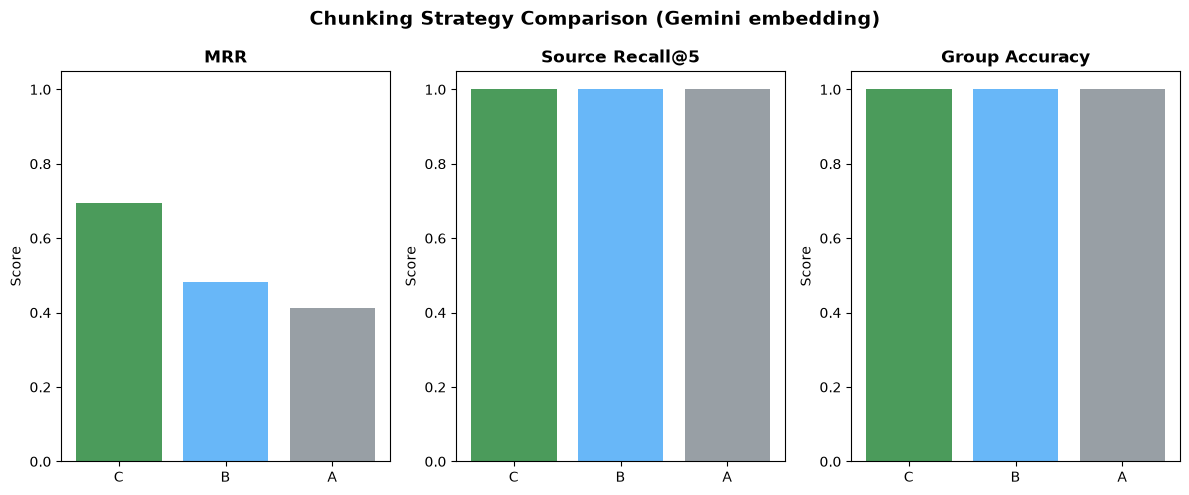

In [41]:
# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

metrics_to_plot = ["MRR", "Source Recall@5", "Group Accuracy"]
colors_by_strategy = {"A": "#868e96", "B": "#4dabf7", "C": "#2b8a3e"}

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(
        summary_df["Strategy"],
        summary_df[metric],
        color=[colors_by_strategy.get(s, "#4dabf7") for s in summary_df["Strategy"]],
        alpha=0.85,
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Chunking Strategy Comparison (Gemini embedding)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("experiment_results.png", dpi=120, bbox_inches="tight")
plt.show()

In [42]:
# ── Before/After: Chunk ตัวอย่างที่ดีขึ้นชัดเจน ──────────────
print("\n📋 BEFORE/AFTER COMPARISON — AOM Pediatric Query")
print("=" * 70)

demo_query = "amoxicillin dose สำหรับเด็กอายุ 18 เดือน AOM รุนแรง"

print(f"\nQuery: '{demo_query}'")
print("\n❌ Strategy A — Top chunk retrieved:")
kw_a = keyword_search(demo_query, chunks_A, top_k=1)[0]
print(f"  heading  : {kw_a['heading']}")
print(f"  type     : {kw_a['type']}")
print(f"  tokens   : {kw_a['tokens_approx']}")
print(f"  content  : {kw_a['content'][:300]}...")

print("\n✅ Strategy C — Top chunk retrieved:")
kw_c = keyword_search(demo_query, chunks_C_eval, top_k=1)[0]
print(f"  heading       : {kw_c['heading']}")
print(f"  type          : {kw_c['type']}")
print(f"  patient_group : {kw_c.get('patient_group', 'N/A')}")
print(f"  tokens        : {kw_c['tokens_approx']}")
print(f"  content       : {kw_c['content'][:300]}...")


📋 BEFORE/AFTER COMPARISON — AOM Pediatric Query

Query: 'amoxicillin dose สำหรับเด็กอายุ 18 เดือน AOM รุนแรง'

❌ Strategy A — Top chunk retrieved:
  heading  : การตรวจทางห้องปฏิบัติการ > แนวทางการป้องกันไซนัสอักเสบ (prevention and promotion) [C1+]
  type     : table_html
  tokens   : 5802
  content  : [Source: URI | Page: 40 | Section: การตรวจทางห้องปฏิบัติการ > แนวทางการป้องกันไซนัสอักเสบ (prevention and promotion) [C1+]]

<table><tr><td>ยา</td><td>ขนาดยา</td><td>ระยะเวลา (วัน)</td></tr><tr><td colspan="3">สำหรับผู้ที่ไม่แพ้ penicillin</td></tr><tr><td>Amixicillin</td><td>40-50 มก./กก./วัน หรือ ...

✅ Strategy C — Top chunk retrieved:
  heading       : UPPER RESPIRATORY TRACT INFECTIONS > Interventions to Reduce Unnecessary Antibiotic Use in Acute URIs > Table
  type          : table_html
  patient_group : both
  tokens        : 1000
  content       : [Source: AAFP | Page: 6 | Section: UPPER RESPIRATORY TRACT INFECTIONS > Interventions to Reduce Unnecessary Antibiotic Use in Acute UR

In [43]:
# ── สรุปข้อเสนอแนะ ────────────────────────────────────────────
best = summary_df.iloc[0]
c_row = summary_df[summary_df["Strategy"] == "C"].iloc[0] if (summary_df["Strategy"] == "C").any() else best

print("\n" + "=" * 70)
print("🏆 RECOMMENDATION — Run 2")
print("=" * 70)
print(f"""
Strategy ที่ดีที่สุด : {best['Strategy']}
MRR                 : {best['MRR']}
Source Recall@5     : {best['Source Recall@5']}
Page Recall (journal): {c_row.get('Page Recall@5 (journal)', 'n/a')}
Page Recall (pdf)    : {c_row.get('Page Recall@5 (pdf)', 'n/a')}  ← Run1 ใช้ตัวนี้ได้ 0.12

สถานะ production:
✅ Strategy C + parser fix + patient_group อยู่ใน md_chunker.py แล้ว
✅ page = PDF (เว็บใช้ #page=N) | journal_page = เลขวารสาร (eval)

ถัดไป:
1. Dose supportive layer
2. ปรับ frontend แสดง journal_page ใน [Ref] (ถ้าต้องการ)
3. BM25/hybrid rerank (ablation ใน Section 6.5)
""")
print("=" * 70)



🏆 RECOMMENDATION — Run 2

Strategy ที่ดีที่สุด : C
MRR                 : 0.695
Source Recall@5     : 1.0
Page Recall (journal): 0.64
Page Recall (pdf)    : 0.12  ← Run1 ใช้ตัวนี้ได้ 0.12

สถานะ production:
✅ Strategy C + parser fix + patient_group อยู่ใน md_chunker.py แล้ว
✅ page = PDF (เว็บใช้ #page=N) | journal_page = เลขวารสาร (eval)

ถัดไป:
1. Dose supportive layer
2. ปรับ frontend แสดง journal_page ใน [Ref] (ถ้าต้องการ)
3. BM25/hybrid rerank (ablation ใน Section 6.5)

